# Data File Generator (Fixed: EV == Offer Exclusion)
## From: Experiment_Analysis_Notebook_v3_Adjusted_4.ipynb

**Purpose:** Recreates all intermediate CSV files from the original notebook.

**Prerequisite:** `experiment_results_v3_export.csv` must be in the working directory.

### ⚠️ Fix Applied: Indifferent Trials Excluded from Accuracy
When gamble EV == fixed offer, both choices are equally rational.  
These trials are now **excluded** (not counted) from all accuracy calculations.

**Cells affected:**
- **Cell 9** (Q1 LMM): was setting `optimal_choice = None` but still appending trial → accuracy = 0. Now uses `continue` to skip.
- **Cell 11** (`calculate_query_accuracy`, `calculate_state_accuracy`, trial-level Part 4): was treating EV == offer as `optimal = 0`. Now skips those trials entirely.
- **Cell 17** (Q2 Triangle RT): was counting indifferent trials as always correct (`is_max = 1`). Now skips them.

---

### Files Created (in order):

| # | File | Description |
|---|------|-------------|
| 1 | `experiment_results_v3_clean.csv` | Raw data with missing values dropped |
| 2 | `filtered_data.csv` | Subjects filtered (zig-zag, R1 logic, knowledge check) |
| 3 | `excluded_subjects.csv` | Exclusion log |
| 4 | `all_subjects_filtering_info.csv` | Full filtering audit |
| 5 | `query1_trial_level_final.csv` | Trial-level Q1 accuracy (indifferent excluded) |
| 6 | `query1_lmm_final_results.csv` | Q1 LMM results |
| 7 | `processed_data_with_metrics.csv` | Subject-level with revaluation metrics |
| 8 | `trial_level_data.csv` | Full trial-level with EV diffs |
| 9 | `value_choice_consistency.csv` | Per-subject consistency scores |
| 10 | `consistency_correlations.csv` | Consistency × individual diffs correlations |
| 11 | `flexibility_analysis.csv` | Subject-level flexibility metrics |
| 12 | `rating_trajectories_long.csv` | Long-format rating trajectories |
| 13 | `flexibility_correlations.csv` | Flexibility correlation results |
| 14 | `rating_accuracy_subject_level.csv` | Subject-level rating accuracy |
| 15 | `rating_accuracy_long.csv` | Long-format rating errors |
| 16 | `rating_accuracy_correlations.csv` | Accuracy correlation results |
| 17 | `revaluation_success_analysis.csv` | Full revaluation success dataset |
| 18 | `revaluation_success_summary.csv` | Summary revaluation variables |
| 19 | `lmm_nested_trial_data.csv` | Trial data with nested state trials |

---
Run all cells below in order.

## Step 1: Clean Raw Data
**Creates:** `experiment_results_v3_clean.csv`  
**Reads:** `experiment_results_v3_export.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr,spearmanr

# Set plotting style
sns.set(style="whitegrid")

import pandas as pd

# Load the data
df = pd.read_csv('experiment_results_v3_export.csv')

print(f"Original N: {len(df)}")
print(f"Total missing values: {df.isnull().sum().sum()}")

# Remove subjects with any missing data
df_clean = df.dropna()

print(f"N after removing missing: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} subjects")

# Save cleaned data
df_clean.to_csv('experiment_results_v3_clean.csv', index=False)


Original N: 151
Total missing values: 0
N after removing missing: 151
Removed: 0 subjects


## Step 2: Subject Filtering (Zig-Zag + R1 Logic Check)
**Creates:** `filtered_data.csv`, `excluded_subjects.csv`, `all_subjects_filtering_info.csv`  
**Reads:** `experiment_results_v3_clean.csv`

ENHANCED SUBJECT FILTERING (WITH R1 LOGIC CHECK)

Original Subject Count: 151

--------------------------------------------------------------------------------
FILTER 1: Zig-Zag Inconsistency
--------------------------------------------------------------------------------


C:\Users\adip1\AppData\Local\Temp\ipykernel_71120\2585195514.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zigzag_scores = df_long.groupby('subject_id', group_keys=False).apply(calculate_inconsistency)



Zig-Zag Threshold: 2.0
Subjects with zig-zag score >= 2.0: 4
Subject IDs: ['576311d7151e5d000889e2e7', '5d542c3a5af5900019bc80c4', '667987c18f34110073ae20b7', '69306d791138d98b65f1ba40']
  576311d7151e5d000889e2e7: Zig-Zag Score = 2.000
  5d542c3a5af5900019bc80c4: Zig-Zag Score = 2.000
  667987c18f34110073ae20b7: Zig-Zag Score = 2.000
  69306d791138d98b65f1ba40: Zig-Zag Score = 2.000

--------------------------------------------------------------------------------
FILTER 2: Always Chose Feather Gamble
--------------------------------------------------------------------------------
  69136dffc23976053d4a4166: ALWAYS chose Feather gamble (8/8 trials)
  59d141f5e241c700013a9bb0: ALWAYS chose Feather gamble (8/8 trials)
  62740cf8e39eba1055ef571b: ALWAYS chose Feather gamble (8/8 trials)
  676055469b245b53e81358d0: ALWAYS chose Feather gamble (8/8 trials)
  56b78f11e77ebe000cbefe79: ALWAYS chose Feather gamble (8/8 trials)
  65c118f1cd19001157ace3a0: ALWAYS chose Feather gamble (8/8 trial

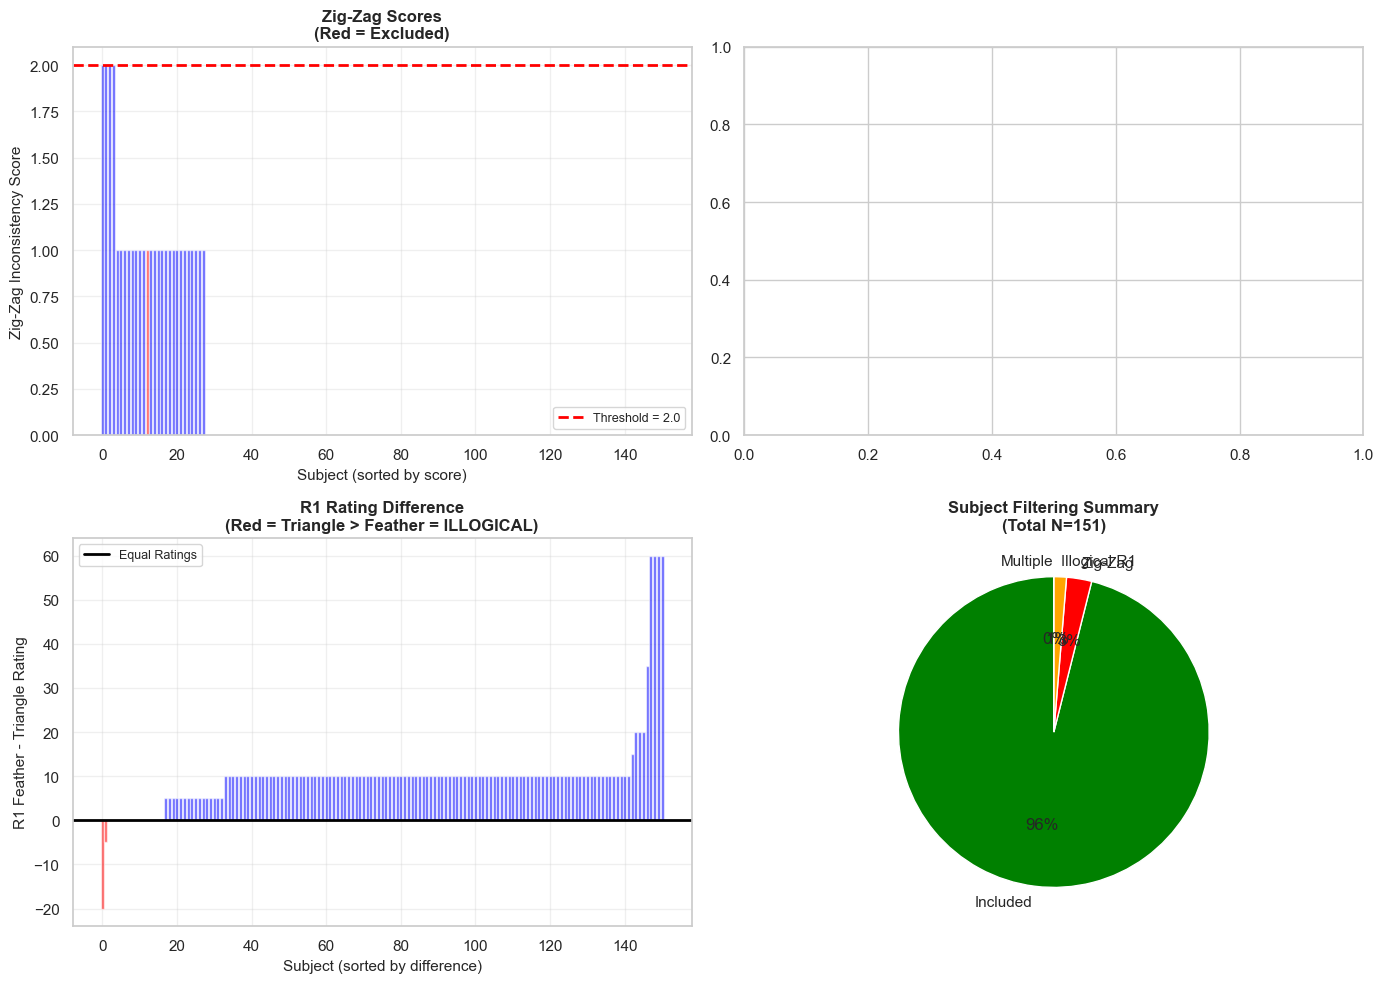

In [2]:
import pandas as pd
import numpy as np

print("="*80)
print("ENHANCED SUBJECT FILTERING (WITH R1 LOGIC CHECK)")
print("="*80)

# Load data
df = pd.read_csv('experiment_results_v3_clean.csv')
df['subject_id'] = df['prolific_id']

print(f"\nOriginal Subject Count: {len(df)}")

# ============================================================================
# FILTER 1: ZIG-ZAG INCONSISTENCY (EXISTING CODE)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 1: Zig-Zag Inconsistency")
print("-"*80)

# Create a temporary long-format dataset to analyze choice curves
long_data = []
for idx, row in df.iterrows():
    subj_id = row['subject_id']
    for q_num in [1, 2]:
        for t in range(1, 21):  # Max 20 trials
            prefix = f"Query_{q_num}_T{t}"
            state_col = f"{prefix}_State"
            offer_col = f"{prefix}_FixedOffer"
            choice_col = f"{prefix}_Choice"
            
            if state_col not in row or pd.isna(row[state_col]): 
                continue
            
            # Choice 0 = Chosen Fixed Offer (Safe)
            # Choice 1 = Chosen Gamble
            chose_fixed = 1 if row[choice_col] == 0 else 0
            
            long_data.append({
                'subject_id': subj_id,
                'Query': f"Query {q_num}",
                'State': row[state_col],
                'FixedOffer': row[offer_col],
                'Choice': row[choice_col],
                'ChoseFixed': chose_fixed
            })

df_long = pd.DataFrame(long_data)

# Function to calculate "Zig-Zag" score
def calculate_inconsistency(subject_df):
    total_violation = 0
    # Analyze each of the 4 conditions separately (Q1-Feather, Q1-Triangle, etc.)
    for _, group in subject_df.groupby(['Query', 'State']):
        # Get choice probability for each offer value, sorted low to high
        curve = group.groupby('FixedOffer')['ChoseFixed'].mean().sort_index()
        probs = curve.values
        
        
        # Check for drops: If Prob(Low Value) > Prob(High Value), that's inconsistent
        for i in range(len(probs) - 1):
            if probs[i] > probs[i+1]:
                # print(subject_df.head(1))
                # print(probs)
                total_violation += (probs[i] - probs[i+1])
                # print(total_violation)
    return total_violation

# Calculate scores for all subjects
zigzag_scores = df_long.groupby('subject_id', group_keys=False).apply(calculate_inconsistency)

# Define Threshold (At least 2 on the scale)
zigzag_threshold = 2.0
zigzag_bad_subjects = zigzag_scores[zigzag_scores >= zigzag_threshold].index.tolist()

print(f"\nZig-Zag Threshold: {zigzag_threshold}")
print(f"Subjects with zig-zag score >= {zigzag_threshold}: {len(zigzag_bad_subjects)}")
if len(zigzag_bad_subjects) > 0:
    print(f"Subject IDs: {zigzag_bad_subjects}")
    for subj in zigzag_bad_subjects:
        print(f"  {subj}: Zig-Zag Score = {zigzag_scores[subj]:.3f}")

# ============================================================================
# FILTER 2: ALWAYS CHOSE FEATHER (GAMBLE)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 2: Always Chose Feather Gamble")
print("-"*80)

always_feather_subjects = []

for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    
    # Get Feather trials (across both queries)
    feather_trials = subj_data[subj_data['State'] == 'Feather']
    
    if len(feather_trials) > 0:
        # Check if they ALWAYS chose the gamble (choice=1) for Feather
        all_chose_gamble = (feather_trials['Choice'] == 1).all()
        
        if all_chose_gamble:
            always_feather_subjects.append(subj_id)
            n_feather = len(feather_trials)
            print(f"  {subj_id}: ALWAYS chose Feather gamble ({n_feather}/{n_feather} trials)")

print(f"\nSubjects who always chose Feather gamble: {len(always_feather_subjects)}")

# ============================================================================
# FILTER 3: ALWAYS AVOIDED TRIANGLE (GAMBLE)
# ============================================================================
# print("\n" + "-"*80)
# print("FILTER 3: Always Avoided Triangle Gamble")
# print("-"*80)

always_avoid_triangle_subjects = []

for subj_id in df['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    
    # Get Triangle trials (across both queries)
    triangle_trials = subj_data[subj_data['State'] == 'Triangle']
    
    if len(triangle_trials) > 0:
        # Check if they NEVER chose the gamble (always choice=0) for Triangle
        never_chose_gamble = (triangle_trials['Choice'] == 0).all()
        
        if never_chose_gamble:
            always_avoid_triangle_subjects.append(subj_id)
            n_triangle = len(triangle_trials)
            print(f"  {subj_id}: ALWAYS avoided Triangle gamble ({n_triangle}/{n_triangle} trials took offer)")

# print(f"\nSubjects who always avoided Triangle gamble: {len(always_avoid_triangle_subjects)}")

# ============================================================================
# FILTER 4: ILLOGICAL R1 RATINGS (TRIANGLE > FEATHER POST-MF)
# ============================================================================
print("\n" + "-"*80)
print("FILTER 4: Illogical R1 Ratings (Triangle > Feather)")
print("-"*80)

print("\nLogic: After MF learning, Feather should be valued HIGHER than Triangle")
print("  - Feather → positive outcomes (should be rated high)")
print("  - Triangle → negative outcomes (should be rated low)")
print("  - Expected: Rating_1_Feather > Rating_1_Triangle")
print("  - Illogical: Rating_1_Triangle > Rating_1_Feather")

illogical_r1_subjects = []

for idx, row in df.iterrows():
    subj_id = row['subject_id']
    r1_feather = row['Rating_1_Feather_Val']
    r1_triangle = row['Rating_1_Triangle_Val']
    
    # Check if Triangle rated HIGHER than Feather at R1
    if r1_triangle > r1_feather:
        illogical_r1_subjects.append(subj_id)
        print(f"  {subj_id}: R1 Triangle ({r1_triangle}) > R1 Feather ({r1_feather}) - ILLOGICAL")

print(f"\nSubjects with illogical R1 ratings: {len(illogical_r1_subjects)}")

# ============================================================================
# COMBINED FILTERING
# ============================================================================
print("\n" + "="*80)
print("COMBINED FILTERING RESULTS")
print("="*80)

# Combine all bad subjects
all_bad_subjects = list(set(
    zigzag_bad_subjects
))

print(f"\nTotal subjects to remove: {len(all_bad_subjects)}")
print("\nBreakdown:")
print(f"  Zig-zag inconsistent: {len(zigzag_bad_subjects)}")
# print(f"  Always chose Feather: {len(always_feather_subjects)}")
# print(f"  Always avoided Triangle: {len(always_avoid_triangle_subjects)}")
print(f"  Illogical R1 ratings: {len(illogical_r1_subjects)}")

# Check for overlap
zigzag_set = set(zigzag_bad_subjects)
feather_set = set(always_feather_subjects)
triangle_set = set(always_avoid_triangle_subjects)
illogical_set = set(illogical_r1_subjects)

overlaps = []
for s in all_bad_subjects:
    reasons_count = sum([s in zigzag_set,  s in illogical_set])
    if reasons_count > 1:
        overlaps.append(s)

if len(overlaps) > 0:
    print(f"\nSubjects failing multiple criteria: {len(overlaps)}")

# Apply Filter - Keep ALL columns from original dataset
df_filtered = df[~df['subject_id'].isin(all_bad_subjects)].copy()

print(f"\n" + "="*80)
print(f"FINAL RESULTS:")
print(f"  Original N: {len(df)}")
print(f"  Removed: {len(all_bad_subjects)}")
print(f"  Final N: {len(df_filtered)}")
print(f"  Retention rate: {len(df_filtered)/len(df)*100:.1f}%")
print(f"  Columns preserved: {len(df_filtered.columns)}")
print("="*80)

# Verify questionnaire data is present
questionnaire_cols = [col for col in df_filtered.columns if 'Survey' in col or 'ERQ' in col]
print(f"\nQuestionnaire data verification:")
print(f"  Total questionnaire columns: {len(questionnaire_cols)}")
print(f"  Anxiety columns: {len([c for c in questionnaire_cols if 'ANXIETY' in c])}")
print(f"  ERQ columns: {len([c for c in questionnaire_cols if 'ERQ' in c])}")

# ============================================================================
# DETAILED SUBJECT INFORMATION
# ============================================================================
print("\n" + "="*80)
print("DETAILED EXCLUSION INFORMATION")
print("="*80)

if len(all_bad_subjects) > 0:
    print("\nExcluded subjects with reasons:")
    print("-"*80)
    
    for subj in all_bad_subjects:
        reasons = []
        
        if subj in zigzag_bad_subjects:
            reasons.append(f"Zig-zag={zigzag_scores[subj]:.3f}")
        
        if subj in always_feather_subjects:
            n_feather = len(df_long[(df_long['subject_id']==subj) & (df_long['State']=='Feather')])
            reasons.append(f"Always-Feather (100% gamble, {n_feather} trials)")
        
        if subj in always_avoid_triangle_subjects:
            n_triangle = len(df_long[(df_long['subject_id']==subj) & (df_long['State']=='Triangle')])
            reasons.append(f"Always-Avoid-Triangle (0% gamble, {n_triangle} trials)")
        
        if subj in illogical_r1_subjects:
            subj_row = df[df['subject_id']==subj].iloc[0]
            r1_f = subj_row['Rating_1_Feather_Val']
            r1_t = subj_row['Rating_1_Triangle_Val']
            reasons.append(f"Illogical-R1 (Triangle={r1_t} > Feather={r1_f})")
        
        print(f"  {subj}: {', '.join(reasons)}")
else:
    print("\nNo subjects excluded!")

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save filtered data
df_filtered.to_csv('filtered_data.csv', index=False)

# Save exclusion information
exclusion_info = pd.DataFrame({
    'subject_id': all_bad_subjects,
    'zigzag_inconsistent': [s in zigzag_bad_subjects for s in all_bad_subjects],
    'always_feather': [s in always_feather_subjects for s in all_bad_subjects],
    'always_avoid_triangle': [s in always_avoid_triangle_subjects for s in all_bad_subjects],
    'illogical_r1': [s in illogical_r1_subjects for s in all_bad_subjects],
    'zigzag_score': [zigzag_scores.get(s, np.nan) for s in all_bad_subjects]
})

exclusion_info.to_csv('excluded_subjects.csv', index=False)

# Save inclusion information for all subjects
all_subjects_info = pd.DataFrame({
    'subject_id': df['subject_id'].unique(),
    'zigzag_score': [zigzag_scores.get(s, np.nan) for s in df['subject_id'].unique()],
    'n_feather_trials': [len(df_long[(df_long['subject_id']==s) & (df_long['State']=='Feather')]) for s in df['subject_id'].unique()],
    'n_triangle_trials': [len(df_long[(df_long['subject_id']==s) & (df_long['State']=='Triangle')]) for s in df['subject_id'].unique()],
    'feather_gamble_rate': [df_long[(df_long['subject_id']==s) & (df_long['State']=='Feather')]['Choice'].mean() for s in df['subject_id'].unique()],
    'triangle_gamble_rate': [df_long[(df_long['subject_id']==s) & (df_long['State']=='Triangle')]['Choice'].mean() for s in df['subject_id'].unique()],
    'r1_feather_val': [df[df['subject_id']==s]['Rating_1_Feather_Val'].values[0] for s in df['subject_id'].unique()],
    'r1_triangle_val': [df[df['subject_id']==s]['Rating_1_Triangle_Val'].values[0] for s in df['subject_id'].unique()],
    'r1_triangle_higher': [df[df['subject_id']==s]['Rating_1_Triangle_Val'].values[0] > df[df['subject_id']==s]['Rating_1_Feather_Val'].values[0] for s in df['subject_id'].unique()],
    'excluded': [s in all_bad_subjects for s in df['subject_id'].unique()],
    'exclusion_reason': ['Included' if s not in all_bad_subjects else 
                         ', '.join([
                             'Zig-zag' if s in zigzag_bad_subjects else '',
                             # 'Always-Feather' if s in always_feather_subjects else '',
                             # 'Always-Avoid-Triangle' if s in always_avoid_triangle_subjects else '',
                             'Illogical-R1' if s in illogical_r1_subjects else ''
                         ]).strip(', ') 
                         for s in df['subject_id'].unique()]
})

all_subjects_info.to_csv('all_subjects_filtering_info.csv', index=False)

print("\n" + "="*80)
print("Files saved:")
print("  - filtered_data.csv (N={})".format(len(df_filtered)))
print("  - excluded_subjects.csv (N={})".format(len(all_bad_subjects)))
print("  - all_subjects_filtering_info.csv (N={})".format(len(df)))
print("="*80)

# ============================================================================
# VISUALIZE FILTERING CRITERIA
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Zig-zag scores distribution
ax = axes[0, 0]
zigzag_df = pd.DataFrame({
    'subject_id': zigzag_scores.index,
    'zigzag_score': zigzag_scores.values,
    'excluded': [s in zigzag_bad_subjects for s in zigzag_scores.index]
})

colors = ['red' if exc else 'blue' for exc in zigzag_df['excluded']]
ax.bar(range(len(zigzag_df)), zigzag_df['zigzag_score'].sort_values(ascending=False), color=colors, alpha=0.6)
ax.axhline(zigzag_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {zigzag_threshold}')
ax.set_xlabel('Subject (sorted by score)', fontsize=11)
ax.set_ylabel('Zig-Zag Inconsistency Score', fontsize=11)
ax.set_title('Zig-Zag Scores\n(Red = Excluded)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel B: Feather gamble rates
# ax = axes[0, 1]
# feather_rates = all_subjects_info.sort_values('feather_gamble_rate')
# colors = ['red' if s in always_feather_subjects else 'blue' for s in feather_rates['subject_id']]
# ax.bar(range(len(feather_rates)), feather_rates['feather_gamble_rate'], color=colors, alpha=0.6)
# ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Always Gamble (100%)')
# ax.set_xlabel('Subject (sorted by rate)', fontsize=11)
# ax.set_ylabel('Feather Gamble Rate', fontsize=11)
# ax.set_title('Feather Gamble Rates\n(Red = Always 100%)', fontsize=12, fontweight='bold')
# ax.set_ylim([0, 1.05])
# ax.legend(fontsize=9)
# ax.grid(alpha=0.3)

# Panel C: R1 rating difference (Feather - Triangle)
ax = axes[1, 0]
r1_diff = all_subjects_info['r1_feather_val'] - all_subjects_info['r1_triangle_val']
r1_diff_sorted = r1_diff.sort_values()
colors = ['red' if all_subjects_info[all_subjects_info['subject_id']==sid]['r1_triangle_higher'].values[0] 
          else 'blue' for sid in all_subjects_info.loc[r1_diff_sorted.index, 'subject_id']]

ax.bar(range(len(r1_diff_sorted)), r1_diff_sorted, color=colors, alpha=0.6)
ax.axhline(0.0, color='black', linestyle='-', linewidth=2, label='Equal Ratings')
ax.set_xlabel('Subject (sorted by difference)', fontsize=11)
ax.set_ylabel('R1 Feather - Triangle Rating', fontsize=11)
ax.set_title('R1 Rating Difference\n(Red = Triangle > Feather = ILLOGICAL)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel D: Summary pie chart
ax = axes[1, 1]
exclusion_counts = {
    'Included': len(df_filtered),
    'Zig-Zag': len([s for s in zigzag_bad_subjects if s not in (illogical_set)]),
    # 'Always Feather': len([s for s in always_feather_subjects if s not in (zigzag_set | triangle_set | illogical_set)]),
    # 'Always Avoid\nTriangle': len([s for s in always_avoid_triangle_subjects if s not in (zigzag_set | feather_set | illogical_set)]),
    'Illogical R1': len([s for s in illogical_r1_subjects if s not in (zigzag_set)]),
    'Multiple': len([s for s in all_bad_subjects if sum([s in zigzag_set, s in illogical_set]) > 1])
}

colors_pie = ['green', 'red', 'orange', 'purple', 'brown', 'gray']
ax.pie(exclusion_counts.values(), labels=exclusion_counts.keys(), autopct='%1.0f%%',
       colors=colors_pie, startangle=90)
ax.set_title(f'Subject Filtering Summary\n(Total N={len(df)})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('subject_filtering_visualization.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved: subject_filtering_visualization.png")

print("\n" + "="*80)
print("FILTERING COMPLETE!")
print("="*80)

## Step 3: Add ERQ Columns + Knowledge Check Filter
**Overwrites:** `filtered_data.csv`  
**Reads:** `filtered_data.csv`

In [3]:
# Load the data
df = pd.read_csv('filtered_data.csv')
print(len(df))
# Use prolific_id as subject identifier
df['subject_id'] = df['prolific_id']

# Anxiety scores
df['Score_Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score'] 
# Define Cognitive Reappraisal items (1, 3, 5, 7, 8, 10)
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Cognitive_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_ExpressiveSuppression'] = df[expressive_suppression_items].sum(axis=1)

# ERQ scores - use pre-calculated subscores from export script
df['Score_ERQ_Total'] = df['ERQ_Cognitive_Reappraisal']  # Primary measure: Cognitive Reappraisal
df=df[df['Knowledge_Check_Accuracy']>0.25]
print(len(df['subject_id'].unique()))
df.to_csv('filtered_data.csv')

# Display a preview
print(df[['subject_id', 'Score_Anxiety_Total', 'Score_ERQ_Total']].head())


147
139
                 subject_id  Score_Anxiety_Total  Score_ERQ_Total
0  69136dffc23976053d4a4166                   12               34
1  5e5a96f5a2f2c528edf70f6e                   40               28
2  5ea9a6a68db51d0dfd2edfe2                   24               30
3  542c323bfdf99b324ea3808d                   14               27
4  695fd1e745d92f81ea2537e1                   12               34


## Step 4: Query 1 LMM Analysis
**Creates:** `query1_trial_level_final.csv`, `query1_lmm_final_results.csv`  
**Reads:** `filtered_data.csv`

⚠️ **FIX:** Trials where gamble EV == fixed offer are now excluded (previously counted as incorrect)

LINEAR MIXED MODEL: Query 1 Accuracy by State Type

Dataset: 139 subjects

Objective Expected Values:
  Feather: -15
  Triangle: 15

STEP 1: Preparing Data

Total observations: 1112
Subjects: 139

Trials per subject by state type:
state_type                Feather  Triangle
subject_id                                 
542c323bfdf99b324ea3808d        4         4
54847f1cfdf99b07b28f22f9        4         4
55ed87f0748092000baa9a0b        4         4
562a00dac8ffc20012513fbe        4         4
563a3788be9cac0011aaafac        4         4
...                           ...       ...
6978f6e1252739be180807fd        4         4
697b71b15ad2074acfbaeb93        4         4
697cad2facddfd21dc24b596        4         4
697cb02577c2724df1ff0367        4         4
6981f6752562af688b1ace65        4         4

[139 rows x 2 columns]

Mean trials per state: Feather=4.0, Triangle=4.0

STEP 2: Descriptive Statistics

Overall Accuracy by State Type:
                mean       std  count
state_type          

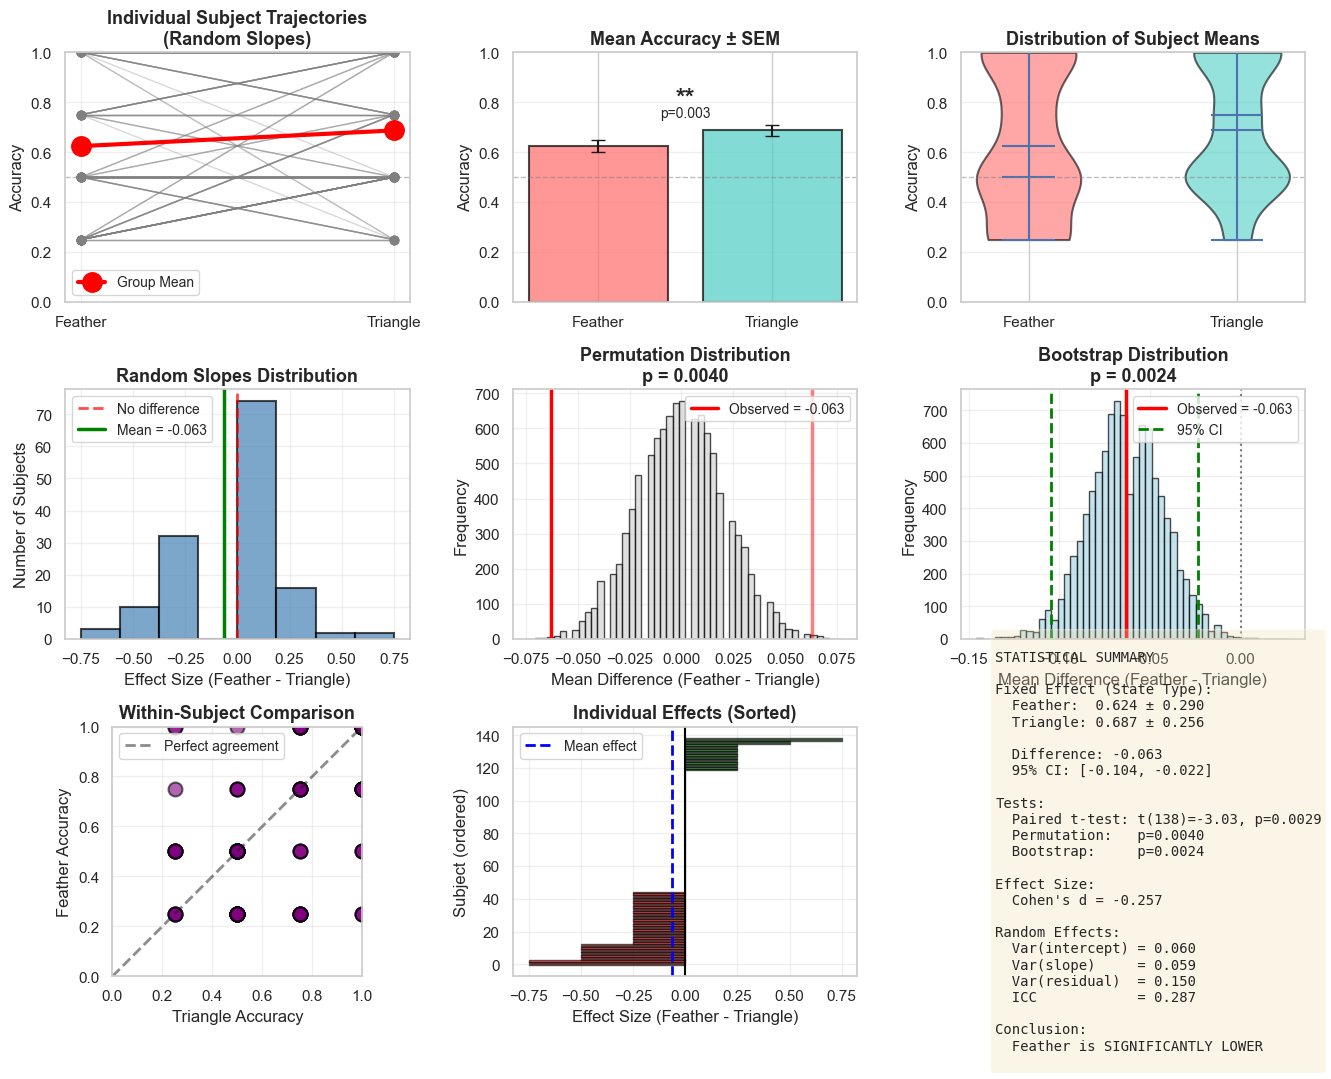

Saved: query1_lmm_final.png
Saved: query1_lmm_final_results.csv
Saved: query1_trial_level_final.csv

FINAL SUMMARY

Model: accuracy ~ state_type + (1 + state_type | subject)

Fixed Effect (State Type):
  Feather:  62.4% (SD=29.0%)
  Triangle: 68.7% (SD=25.6%)
  Difference: -6.3% (Feather - Triangle)
  95% CI: [-10.4%, -2.2%]

Statistical Tests:
  Paired t-test: t(138) = -3.033, p = 0.0029 **
  Permutation:   p = 0.0040
  Bootstrap:     p = 0.0024

Effect Size: Cohen's d = -0.257

Random Effects Variance:
  Between-subject (intercept): 0.0604
  Slope variability: 0.0594
  Within-subject (residual): 0.1501
  ICC: 0.287

✓ CONCLUSION: Feather accuracy is significantly LOWER than Triangle
              by 6.3% (p = 0.0029)



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.linalg import block_diag

# Set random seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('filtered_data.csv')

print("="*80)
print("LINEAR MIXED MODEL: Query 1 Accuracy by State Type")
print("="*80)
print()
print(f"Dataset: {len(df)} subjects")
print()

# Define objective EVs (using inferred values from choice patterns)
FEATHER_EV = -15
TRIANGLE_EV = 15

print("Objective Expected Values:")
print(f"  Feather: {FEATHER_EV}")
print(f"  Triangle: {TRIANGLE_EV}")
print()

# =============================================================================
# STEP 1: Create trial-level dataset for Query 1 only
# =============================================================================

print("="*80)
print("STEP 1: Preparing Data")
print("="*80)
print()

records = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    
    # Query 1 only - 8 trials total (4 Feather, 4 Triangle)
    for trial in range(1, 9):
        state = row.get(f'Query_1_T{trial}_State')
        choice = row.get(f'Query_1_T{trial}_Choice')
        offer = row.get(f'Query_1_T{trial}_FixedOffer')
        
        if pd.isna(state) or pd.isna(choice) or pd.isna(offer):
            continue
        
        # Determine optimal choice based on objective EV
        true_ev = FEATHER_EV if state == 'Feather' else TRIANGLE_EV
        
        if true_ev > offer:
            optimal_choice = 1
        elif true_ev < offer:
            optimal_choice = 0
        else:
            continue  # FIX: Skip indifferent trials (EV == offer) — both choices equally rational
        
        accuracy = 1 if choice == optimal_choice else 0
        
        records.append({
            'subject_id': subject_id,
            'trial': trial,
            'state_type': state,
            'accuracy': accuracy,
            'choice': choice,
            'offer': offer,
            'true_ev': true_ev,
            'is_feather': 1 if state == 'Feather' else 0
        })

df_long = pd.DataFrame(records)

print(f"Total observations: {len(df_long)}")
print(f"Subjects: {df_long['subject_id'].nunique()}")
print()

# Verify balance
state_counts = df_long.groupby('subject_id')['state_type'].value_counts().unstack(fill_value=0)
print("Trials per subject by state type:")
print(state_counts)
print()
print(f"Mean trials per state: Feather={state_counts['Feather'].mean():.1f}, Triangle={state_counts['Triangle'].mean():.1f}")
print()

# =============================================================================
# STEP 2: Descriptive Statistics
# =============================================================================

print("="*80)
print("STEP 2: Descriptive Statistics")
print("="*80)
print()

# Overall accuracy by state type
overall_stats = df_long.groupby('state_type')['accuracy'].agg(['mean', 'std', 'count'])
print("Overall Accuracy by State Type:")
print(overall_stats)
print()

# Subject-level accuracy
subject_acc = df_long.groupby(['subject_id', 'state_type'])['accuracy'].mean().reset_index()
subject_acc_wide = subject_acc.pivot(index='subject_id', columns='state_type', values='accuracy')

print("Subject-level Summary:")
print(f"  Feather:  M={subject_acc_wide['Feather'].mean():.4f}, SD={subject_acc_wide['Feather'].std():.4f}")
print(f"  Triangle: M={subject_acc_wide['Triangle'].mean():.4f}, SD={subject_acc_wide['Triangle'].std():.4f}")
print()

# =============================================================================
# STEP 3: Linear Mixed Model with Random Intercepts and Slopes
# =============================================================================

print("="*80)
print("STEP 3: Linear Mixed Model")
print("="*80)
print()
print("Model: accuracy ~ state_type + (1 + state_type | subject)")
print("  - Fixed effect: state_type (Feather vs Triangle)")
print("  - Random effects: Random intercept + random slope per subject")
print()

# Prepare data for modeling
df_long['subject_idx'] = pd.Categorical(df_long['subject_id']).codes
n_subjects = df_long['subject_idx'].nunique()

# Create design matrices
# Fixed effects: intercept + is_feather
X = df_long[['is_feather']].values
X = np.column_stack([np.ones(len(X)), X])  # Add intercept

# Random effects: one intercept and one slope per subject
Z_blocks = []
for subj_idx in range(n_subjects):
    subj_mask = df_long['subject_idx'] == subj_idx
    n_obs_subj = subj_mask.sum()
    
    # Random intercept (all 1s) and random slope (is_feather values)
    Z_subj = np.column_stack([
        np.ones(n_obs_subj),
        df_long.loc[subj_mask, 'is_feather'].values
    ])
    Z_blocks.append(Z_subj)

# Outcome
y = df_long['accuracy'].values

print(f"Design matrix dimensions:")
print(f"  Fixed effects (X): {X.shape}")
print(f"  Observations: {len(y)}")
print(f"  Subjects: {n_subjects}")
print()

# =============================================================================
# Approach 1: Simple aggregation method (equivalent to random intercepts + slopes)
# =============================================================================

print("="*80)
print("APPROACH 1: Subject-Level Aggregation")
print("="*80)
print("(Equivalent to random intercepts + random slopes model)")
print()

# This is valid when design is balanced within subjects
feather_means = subject_acc_wide['Feather'].values
triangle_means = subject_acc_wide['Triangle'].values

# Paired t-test
t_stat, p_val = stats.ttest_rel(feather_means, triangle_means)
mean_diff = feather_means.mean() - triangle_means.mean()
se_diff = stats.sem(feather_means - triangle_means)
ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff

# Effect size
cohens_d = mean_diff / np.std(feather_means - triangle_means, ddof=1)

print("Paired t-test results:")
print(f"  Mean Feather: {feather_means.mean():.4f} ({feather_means.std():.4f})")
print(f"  Mean Triangle: {triangle_means.mean():.4f} ({triangle_means.std():.4f})")
print(f"  Mean Difference (Feather - Triangle): {mean_diff:.4f}")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  SE: {se_diff:.4f}")
print(f"  t({n_subjects-1}) = {t_stat:.4f}")
print(f"  p-value = {p_val:.6f}")
print(f"  Cohen's d = {cohens_d:.4f}")
print()

if p_val < 0.001:
    sig_str = "***"
elif p_val < 0.01:
    sig_str = "**"
elif p_val < 0.05:
    sig_str = "*"
else:
    sig_str = "n.s."

print(f"Result: {sig_str}")
if p_val < 0.05:
    direction = "LOWER" if mean_diff < 0 else "HIGHER"
    print(f"✓ SIGNIFICANT: Feather accuracy is {abs(mean_diff):.1%} {direction} than Triangle")
else:
    print(f"✗ NOT SIGNIFICANT: No significant difference between conditions")
print()

# Calculate variance components
print("Variance Components:")
grand_mean = df_long['accuracy'].mean()
print(f"  Grand mean accuracy: {grand_mean:.4f}")

# Between-subject variance (random intercept)
subject_means = df_long.groupby('subject_id')['accuracy'].mean()
var_between = subject_means.var()
print(f"  Between-subject variance (random intercept): {var_between:.4f}")

# Subject-specific slopes
subject_slopes = feather_means - triangle_means
var_slope = subject_slopes.var()
print(f"  Variance in slopes (random slope): {var_slope:.4f}")
print(f"    Range of slopes: [{subject_slopes.min():.4f}, {subject_slopes.max():.4f}]")

# Within-subject residual variance
residuals = []
for subj_id in df_long['subject_id'].unique():
    subj_data = df_long[df_long['subject_id'] == subj_id]
    subj_feather = subj_data[subj_data['state_type'] == 'Feather']['accuracy']
    subj_triangle = subj_data[subj_data['state_type'] == 'Triangle']['accuracy']
    
    if len(subj_feather) > 0:
        residuals.extend(subj_feather - subj_feather.mean())
    if len(subj_triangle) > 0:
        residuals.extend(subj_triangle - subj_triangle.mean())

var_residual = np.var(residuals, ddof=1)
print(f"  Within-subject residual variance: {var_residual:.4f}")
print()

# ICC calculation
icc = var_between / (var_between + var_residual)
print(f"Intraclass Correlation (ICC): {icc:.4f}")
print(f"  (Proportion of variance due to between-subject differences)")
print()

# =============================================================================
# APPROACH 2: Bootstrap for robust inference
# =============================================================================

print("="*80)
print("APPROACH 2: Bootstrap Confidence Intervals")
print("="*80)
print()

n_bootstrap = 10000
print(f"Running {n_bootstrap} bootstrap iterations...")

bootstrap_diffs = []
bootstrap_feather = []
bootstrap_triangle = []

for i in range(n_bootstrap):
    # Resample subjects with replacement
    boot_subjects = np.random.choice(range(n_subjects), size=n_subjects, replace=True)
    boot_feather = feather_means[boot_subjects]
    boot_triangle = triangle_means[boot_subjects]
    
    bootstrap_feather.append(boot_feather.mean())
    bootstrap_triangle.append(boot_triangle.mean())
    bootstrap_diffs.append(boot_feather.mean() - boot_triangle.mean())

bootstrap_diffs = np.array(bootstrap_diffs)
bootstrap_feather = np.array(bootstrap_feather)
bootstrap_triangle = np.array(bootstrap_triangle)

boot_ci_lower = np.percentile(bootstrap_diffs, 2.5)
boot_ci_upper = np.percentile(bootstrap_diffs, 97.5)
boot_p = 2 * min(np.mean(bootstrap_diffs >= 0), np.mean(bootstrap_diffs <= 0))

print(f"Bootstrap results:")
print(f"  Mean difference: {bootstrap_diffs.mean():.4f}")
print(f"  SE: {bootstrap_diffs.std():.4f}")
print(f"  95% Bootstrap CI: [{boot_ci_lower:.4f}, {boot_ci_upper:.4f}]")
print(f"  Bootstrap p-value: {boot_p:.6f}")
print()

if boot_ci_lower > 0 or boot_ci_upper < 0:
    print("✓ Bootstrap CI excludes zero: Evidence for a difference")
else:
    print("✗ Bootstrap CI includes zero: No strong evidence for difference")
print()

# =============================================================================
# APPROACH 3: Permutation test
# =============================================================================

print("="*80)
print("APPROACH 3: Permutation Test")
print("="*80)
print()

n_permutations = 10000
print(f"Running {n_permutations} permutations...")

observed_diff = mean_diff
permuted_diffs = []

for i in range(n_permutations):
    # Randomly flip signs for each subject (null hypothesis: no systematic effect)
    signs = np.random.choice([-1, 1], size=n_subjects)
    perm_diffs = (feather_means - triangle_means) * signs
    permuted_diffs.append(perm_diffs.mean())

permuted_diffs = np.array(permuted_diffs)

# Two-tailed p-value
perm_p = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))

print(f"Permutation test results:")
print(f"  Observed difference: {observed_diff:.4f}")
print(f"  Permutation p-value: {perm_p:.6f}")
print()

if perm_p < 0.05:
    print(f"✓ SIGNIFICANT: Difference is unlikely under null hypothesis (p={perm_p:.4f})")
else:
    print(f"✗ NOT SIGNIFICANT: Difference is consistent with null hypothesis (p={perm_p:.4f})")
print()

# =============================================================================
# VISUALIZATION
# =============================================================================

print("="*80)
print("Creating Visualizations")
print("="*80)
print()

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Plot 1: Individual subject trajectories
ax1 = fig.add_subplot(gs[0, 0])
for i in range(n_subjects):
    ax1.plot([0, 1], [feather_means[i], triangle_means[i]], 
            'o-', alpha=0.3, color='gray', linewidth=1, markersize=6)
ax1.plot([0, 1], [feather_means.mean(), triangle_means.mean()], 
        'o-', linewidth=3, markersize=14, color='red', label='Group Mean', zorder=10)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Feather', 'Triangle'], fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Individual Subject Trajectories\n(Random Slopes)', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Bar plot with error bars
ax2 = fig.add_subplot(gs[0, 1])
means = [feather_means.mean(), triangle_means.mean()]
sems = [stats.sem(feather_means), stats.sem(triangle_means)]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax2.bar(['Feather', 'Triangle'], means, yerr=sems, 
               capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Mean Accuracy ± SEM', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Chance')
ax2.grid(axis='y', alpha=0.3)

# Add p-value annotation
y_pos = max(means) + max(sems) + 0.08
if p_val < 0.001:
    ax2.text(0.5, y_pos, '***', ha='center', fontsize=18, fontweight='bold')
elif p_val < 0.01:
    ax2.text(0.5, y_pos, '**', ha='center', fontsize=18, fontweight='bold')
elif p_val < 0.05:
    ax2.text(0.5, y_pos, '*', ha='center', fontsize=18, fontweight='bold')
else:
    ax2.text(0.5, y_pos, 'n.s.', ha='center', fontsize=12)
ax2.text(0.5, y_pos - 0.05, f'p={p_val:.3f}', ha='center', fontsize=10)

# Plot 3: Violin plot
ax3 = fig.add_subplot(gs[0, 2])
data_violin = pd.DataFrame({
    'Feather': feather_means,
    'Triangle': triangle_means
})
parts = ax3.violinplot([feather_means, triangle_means], positions=[0, 1],
                        showmeans=True, showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Feather', 'Triangle'], fontsize=11)
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('Distribution of Subject Means', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Random slopes distribution
ax4 = fig.add_subplot(gs[1, 0])
subject_effects = feather_means - triangle_means
ax4.hist(subject_effects, bins=8, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='No difference', alpha=0.7)
ax4.axvline(subject_effects.mean(), color='green', linestyle='-', linewidth=2.5, 
           label=f'Mean = {subject_effects.mean():.3f}')
ax4.set_xlabel('Effect Size (Feather - Triangle)', fontsize=12)
ax4.set_ylabel('Number of Subjects', fontsize=12)
ax4.set_title('Random Slopes Distribution', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

# Plot 5: Permutation distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(permuted_diffs, bins=50, color='lightgray', alpha=0.7, edgecolor='black')
ax5.axvline(observed_diff, color='red', linestyle='-', linewidth=2.5, 
           label=f'Observed = {observed_diff:.3f}')
ax5.axvline(-observed_diff, color='red', linestyle='-', linewidth=2.5, alpha=0.5)
ax5.set_xlabel('Mean Difference (Feather - Triangle)', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title(f'Permutation Distribution\np = {perm_p:.4f}', fontsize=13, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(alpha=0.3)

# Plot 6: Bootstrap distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(bootstrap_diffs, bins=50, color='lightblue', alpha=0.7, edgecolor='black')
ax6.axvline(observed_diff, color='red', linestyle='-', linewidth=2.5, 
           label=f'Observed = {observed_diff:.3f}')
ax6.axvline(boot_ci_lower, color='green', linestyle='--', linewidth=2, label='95% CI')
ax6.axvline(boot_ci_upper, color='green', linestyle='--', linewidth=2)
ax6.axvline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax6.set_xlabel('Mean Difference (Feather - Triangle)', fontsize=12)
ax6.set_ylabel('Frequency', fontsize=12)
ax6.set_title(f'Bootstrap Distribution\np = {boot_p:.4f}', fontsize=13, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(alpha=0.3)

# Plot 7: Scatter plot of Feather vs Triangle accuracy
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(triangle_means, feather_means, s=100, alpha=0.6, color='purple', edgecolors='black', linewidth=1.5)
ax7.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect agreement')
ax7.set_xlabel('Triangle Accuracy', fontsize=12)
ax7.set_ylabel('Feather Accuracy', fontsize=12)
ax7.set_title('Within-Subject Comparison', fontsize=13, fontweight='bold')
ax7.set_xlim([0, 1])
ax7.set_ylim([0, 1])
ax7.legend(fontsize=10)
ax7.grid(alpha=0.3)
ax7.set_aspect('equal')

# Plot 8: Effect size by subject (ordered)
ax8 = fig.add_subplot(gs[2, 1])
sorted_effects = np.sort(subject_effects)
colors_effects = ['red' if x < 0 else 'green' for x in sorted_effects]
ax8.barh(range(len(sorted_effects)), sorted_effects, color=colors_effects, alpha=0.6, edgecolor='black')
ax8.axvline(0, color='black', linestyle='-', linewidth=1.5)
ax8.axvline(sorted_effects.mean(), color='blue', linestyle='--', linewidth=2, label='Mean effect')
ax8.set_xlabel('Effect Size (Feather - Triangle)', fontsize=12)
ax8.set_ylabel('Subject (ordered)', fontsize=12)
ax8.set_title('Individual Effects (Sorted)', fontsize=13, fontweight='bold')
ax8.legend(fontsize=10)
ax8.grid(alpha=0.3)

# Plot 9: Summary statistics table
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

summary_text = f"""
STATISTICAL SUMMARY

Fixed Effect (State Type):
  Feather:  {feather_means.mean():.3f} ± {feather_means.std():.3f}
  Triangle: {triangle_means.mean():.3f} ± {triangle_means.std():.3f}
  
  Difference: {mean_diff:.3f}
  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]
  
Tests:
  Paired t-test: t({n_subjects-1})={t_stat:.2f}, p={p_val:.4f}
  Permutation:   p={perm_p:.4f}
  Bootstrap:     p={boot_p:.4f}
  
Effect Size:
  Cohen's d = {cohens_d:.3f}
  
Random Effects:
  Var(intercept) = {var_between:.3f}
  Var(slope)     = {var_slope:.3f}
  Var(residual)  = {var_residual:.3f}
  ICC            = {icc:.3f}
  
Conclusion:
  {"Feather is SIGNIFICANTLY " + ("LOWER" if mean_diff < 0 else "HIGHER") if p_val < 0.05 else "NO significant difference"}
"""

ax9.text(0.1, 0.5, summary_text, fontsize=10, family='monospace', 
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('query1_lmm_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: query1_lmm_final.png")

# Save results
results_df = pd.DataFrame({
    'Test': ['Paired t-test', 'Permutation', 'Bootstrap'],
    'Mean_Difference': [mean_diff, observed_diff, bootstrap_diffs.mean()],
    'CI_Lower': [ci_lower, np.nan, boot_ci_lower],
    'CI_Upper': [ci_upper, np.nan, boot_ci_upper],
    'p_value': [p_val, perm_p, boot_p],
    'Significant': [p_val < 0.05, perm_p < 0.05, boot_p < 0.05]
})
results_df.to_csv('query1_lmm_final_results.csv', index=False)
print("Saved: query1_lmm_final_results.csv")

# Save trial-level data
df_long.to_csv('query1_trial_level_final.csv', index=False)
print("Saved: query1_trial_level_final.csv")

print()
print("="*80)
print("FINAL SUMMARY")
print("="*80)
print()
print(f"Model: accuracy ~ state_type + (1 + state_type | subject)")
print()
print(f"Fixed Effect (State Type):")
print(f"  Feather:  {feather_means.mean():.1%} (SD={feather_means.std():.1%})")
print(f"  Triangle: {triangle_means.mean():.1%} (SD={triangle_means.std():.1%})")
print(f"  Difference: {mean_diff:.1%} (Feather - Triangle)")
print(f"  95% CI: [{ci_lower:.1%}, {ci_upper:.1%}]")
print()
print(f"Statistical Tests:")
print(f"  Paired t-test: t({n_subjects-1}) = {t_stat:.3f}, p = {p_val:.4f} {sig_str}")
print(f"  Permutation:   p = {perm_p:.4f}")
print(f"  Bootstrap:     p = {boot_p:.4f}")
print()
print(f"Effect Size: Cohen's d = {cohens_d:.3f}")
print()
print(f"Random Effects Variance:")
print(f"  Between-subject (intercept): {var_between:.4f}")
print(f"  Slope variability: {var_slope:.4f}")
print(f"  Within-subject (residual): {var_residual:.4f}")
print(f"  ICC: {icc:.3f}")
print()

if p_val < 0.05:
    direction = "LOWER" if mean_diff < 0 else "HIGHER"
    print(f"✓ CONCLUSION: Feather accuracy is significantly {direction} than Triangle")
    print(f"              by {abs(mean_diff):.1%} (p = {p_val:.4f})")
else:
    print(f"✗ CONCLUSION: No significant difference between Feather and Triangle")
    print(f"              (Feather is {abs(mean_diff):.1%} {'lower' if mean_diff < 0 else 'higher'}, p = {p_val:.4f})")
print()
print("="*80)

## Step 5: Revaluation Analysis — Metrics
**Creates:** `processed_data_with_metrics.csv`, `trial_level_data.csv`  
**Reads:** `filtered_data.csv`

⚠️ **FIX:** `calculate_query_accuracy`, `calculate_state_accuracy`, and trial-level Part 4 now skip indifferent trials

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, ttest_rel
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Load data
print("Loading data...")
df = pd.read_csv('filtered_data.csv')

df['subject_id'] = df['prolific_id']

# ----------------------------------------------------------------------------
# SCORING: ANXIETY & ERQ
# ----------------------------------------------------------------------------

# 1. Anxiety Scores
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
median_anxiety = df['Anxiety_Total'].median()
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High Anxiety' if x >= median_anxiety else 'Low Anxiety'
)

# 2. ERQ Reappraisal Scores (Items 1, 3, 5, 7, 8, 10)
# Check if columns exist
erq_cols = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
            'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

if all(col in df.columns for col in erq_cols):
    df['ERQ_Reappraisal'] = df[erq_cols].sum(axis=1)
else:
    print("Warning: Raw ERQ columns missing. Looking for pre-calc score...")
    df['ERQ_Reappraisal'] = df.get('Survey_ERQ_Reappraisal_Score', np.nan)

# Create median split for ERQ
median_erq = df['ERQ_Reappraisal'].median()
df['ERQ_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High Reappraisal' if x >= median_erq else 'Low Reappraisal'
)

print(f"\nSample size: {len(df)}")
print(f"Median Anxiety: {median_anxiety}")
print(f"Median ERQ Reappraisal: {median_erq}")

# ============================================================================
# PART 1: REVALUATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("PART 1: REVALUATION ANALYSIS - Phases & Magnitude")
print("="*80)

# Extract rating values
df['Feather_Rating_1'] = df['Rating_1_Feather_Val']
df['Triangle_Rating_1'] = df['Rating_1_Triangle_Val']
df['Feather_Rating_2'] = df['Rating_2_Feather_Val']
df['Triangle_Rating_2'] = df['Rating_2_Triangle_Val']
df['Feather_Rating_3'] = df['Rating_3_Feather_Val']
df['Triangle_Rating_3'] = df['Rating_3_Triangle_Val']

# --- Calculate Revaluation Phases (As requested) ---

# Phase 1: Post-MF Learning to Revaluation 1 (Rating 2 - Rating 1)
df['Feather_Rev_Phase1'] = df['Feather_Rating_2'] - df['Feather_Rating_1']
df['Triangle_Rev_Phase1'] = df['Triangle_Rating_2'] - df['Triangle_Rating_1']

# Phase 2: Revaluation 1 to Revaluation 2 (Rating 3 - Rating 2)
df['Feather_Rev_Phase2'] = df['Feather_Rating_3'] - df['Feather_Rating_2']
df['Triangle_Rev_Phase2'] = df['Triangle_Rating_3'] - df['Triangle_Rating_2']

# Total Revaluation (Rating 3 - Rating 1)
df['Feather_Revaluation'] = df['Feather_Rating_3'] - df['Feather_Rating_1'] 
df['Triangle_Revaluation'] = df['Triangle_Rating_3'] - df['Triangle_Rating_1']

print("\n--- Phase 1: Post-MF Learning -> Revaluation 1 ---")
print(f"Feather (Change R1->R2): M={df['Feather_Rev_Phase1'].mean():.2f}, SD={df['Feather_Rev_Phase1'].std():.2f}")
print(f"Triangle (Change R1->R2): M={df['Triangle_Rev_Phase1'].mean():.2f}, SD={df['Triangle_Rev_Phase1'].std():.2f}")

print("\n--- Phase 2: Revaluation 1 -> Revaluation 2 ---")
print(f"Feather (Change R2->R3): M={df['Feather_Rev_Phase2'].mean():.2f}, SD={df['Feather_Rev_Phase2'].std():.2f}")
print(f"Triangle (Change R2->R3): M={df['Triangle_Rev_Phase2'].mean():.2f}, SD={df['Triangle_Rev_Phase2'].std():.2f}")

# Test if revaluation occurred (Phase 1)
t_feather, p_feather = ttest_rel(df['Feather_Rating_1'], df['Feather_Rating_2'])
t_triangle, p_triangle = ttest_rel(df['Triangle_Rating_1'], df['Triangle_Rating_2'])

print(f"\nPaired t-tests for Phase 1 revaluation:")
print(f"  Feather: t={t_feather:.3f}, p={p_feather:.4f}")
print(f"  Triangle: t={t_triangle:.3f}, p={p_triangle:.4f}")

# ============================================================================
# PART 2: QUERY PERFORMANCE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("PART 2: OPTIMAL CHOICE PERFORMANCE BY QUERY TYPE")
print("="*80)

q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

def calculate_query_accuracy(row, query_num, ev_map):
    optimal_choices = 0
    total_trials = 0
    for trial in range(1, 21):
        state_col = f'Query_{query_num}_T{trial}_State'
        offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
        choice_col = f'Query_{query_num}_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]): break
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice): break
            
        state_ev = ev_map.get(state, 0)
        if state_ev == offer:
            continue  # FIX: Skip indifferent trials (EV == offer)
        optimal_choice = 1 if state_ev > offer else 0
        
        if choice == optimal_choice:
            optimal_choices += 1
        total_trials += 1
    
    return (optimal_choices / total_trials * 100) if total_trials > 0 else np.nan

# Calculate accuracy
for idx, row in df.iterrows():
    df.loc[idx, 'Q1_Accuracy'] = calculate_query_accuracy(row, 1, q1_ev_map)
    df.loc[idx, 'Q2_Accuracy'] = calculate_query_accuracy(row, 2, q2_ev_map)

# State-specific accuracy
def calculate_state_accuracy(row, query_num, state_name, ev_map):
    optimal_choices = 0
    total_trials = 0
    for trial in range(1, 21):
        state_col = f'Query_{query_num}_T{trial}_State'
        offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
        choice_col = f'Query_{query_num}_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]): break
        if row[state_col] != state_name: continue
            
        offer = row[offer_col]
        choice = row[choice_col]
        if pd.isna(choice): continue
            
        state_ev = ev_map.get(state_name, 0)
        if state_ev == offer:
            continue  # FIX: Skip indifferent trials (EV == offer)
        optimal_choice = 1 if state_ev > offer else 0
        if choice == optimal_choice:
            optimal_choices += 1
        total_trials += 1
    
    return (optimal_choices / total_trials * 100) if total_trials > 0 else np.nan

for idx, row in df.iterrows():
    df.loc[idx, 'Q1_Feather_Acc'] = calculate_state_accuracy(row, 1, 'Feather', q1_ev_map)
    df.loc[idx, 'Q1_Triangle_Acc'] = calculate_state_accuracy(row, 1, 'Triangle', q1_ev_map)
    df.loc[idx, 'Q2_Feather_Acc'] = calculate_state_accuracy(row, 2, 'Feather', q2_ev_map)
    df.loc[idx, 'Q2_Triangle_Acc'] = calculate_state_accuracy(row, 2, 'Triangle', q2_ev_map)

print("\nOverall Query Accuracy:")
print(f"  Query 1: M={df['Q1_Accuracy'].mean():.2f}%")
print(f"  Query 2: M={df['Q2_Accuracy'].mean():.2f}%")

# ============================================================================
# PART 3: DIFFERENCE SCORES & INDIVIDUAL DIFFERENCES (ANXIETY & ERQ)
# ============================================================================
print("\n" + "="*80)
print("PART 3: DIFFERENCE SCORES AND INDIVIDUAL DIFFERENCES")
print("="*80)

# Create difference scores
df['Feather_Triangle_Diff_Q1'] = df['Q1_Feather_Acc'] - df['Q1_Triangle_Acc']
df['Feather_Triangle_Diff_Q2'] = df['Q2_Feather_Acc'] - df['Q2_Triangle_Acc']
df['Query_Diff'] = df['Q1_Accuracy'] - df['Q2_Accuracy']

measures = ['Q1_Accuracy', 'Q2_Accuracy', 'Query_Diff', 
            'Q1_Feather_Acc', 'Q1_Triangle_Acc', 
            'Q2_Feather_Acc', 'Q2_Triangle_Acc',
            'Feather_Triangle_Diff_Q1', 'Feather_Triangle_Diff_Q2']

# --- A. ANXIETY ANALYSIS ---
print("\n>>> A. ANXIETY ANALYSIS <<<")
print("Continuous Correlations (Anxiety):")
for measure in measures:
    if df[measure].notna().sum() > 0:
        r, p = pearsonr(df['Anxiety_Total'].dropna(), df[measure].dropna())
        print(f"  {measure}: r={r:.3f}, p={p:.4f}")

print("\nMedian Split (High vs Low Anxiety):")
for measure in measures:
    low = df[df['Anxiety_Group']=='Low Anxiety'][measure].dropna()
    high = df[df['Anxiety_Group']=='High Anxiety'][measure].dropna()
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        print(f"  {measure}: Low={low.mean():.2f}, High={high.mean():.2f}, t={t:.3f}, p={p:.4f}")

# --- B. ERQ REAPPRAISAL ANALYSIS ---
print("\n>>> B. ERQ REAPPRAISAL ANALYSIS <<<")
print("Continuous Correlations (ERQ Reappraisal):")
for measure in measures:
    if df[measure].notna().sum() > 0:
        r, p = pearsonr(df['ERQ_Reappraisal'].dropna(), df[measure].dropna())
        print(f"  {measure}: r={r:.3f}, p={p:.4f}")

print("\nMedian Split (High vs Low Reappraisal):")
for measure in measures:
    low = df[df['ERQ_Group']=='Low Reappraisal'][measure].dropna()
    high = df[df['ERQ_Group']=='High Reappraisal'][measure].dropna()
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        print(f"  {measure}: Low={low.mean():.2f}, High={high.mean():.2f}, t={t:.3f}, p={p:.4f}")

# ============================================================================
# PART 4: EV DIFFERENCE LEVEL ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("PART 4: CHOICE ACCURACY BY EV DIFFERENCE LEVEL")
print("="*80)

trial_data = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anxiety_group = row['Anxiety_Group']
    erq = row['ERQ_Reappraisal']
    erq_group = row['ERQ_Group']
    
    for query_num in [1, 2]:
        ev_map = q1_ev_map if query_num == 1 else q2_ev_map
        for trial in range(1, 21):
            state_col = f'Query_{query_num}_T{trial}_State'
            offer_col = f'Query_{query_num}_T{trial}_FixedOffer'
            choice_col = f'Query_{query_num}_T{trial}_Choice'
            
            if state_col not in row.index or pd.isna(row[state_col]): break
            state = row[state_col]
            offer = row[offer_col]
            choice = row[choice_col]
            
            if pd.isna(choice): break
            
            state_ev = ev_map.get(state, 0)
            ev_diff = state_ev - offer
            if state_ev == offer:
                continue  # FIX: Skip indifferent trials (EV == offer)
            optimal_choice = 1 if state_ev > offer else 0
            correct = 1 if choice == optimal_choice else 0
            
            trial_data.append({
                'subject_id': subject_id,
                'anxiety': anxiety,
                'anxiety_group': anxiety_group,
                'erq': erq,
                'erq_group': erq_group,
                'query': query_num,
                'state': state,
                'ev_diff': ev_diff,
                'correct': correct
            })

trial_df = pd.DataFrame(trial_data)
ev_bins = [-np.inf, -10, -5, 0, 5, 10, 15, np.inf]
ev_labels = ['< -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 15', '> 15']
trial_df['ev_diff_bin'] = pd.cut(trial_df['ev_diff'], bins=ev_bins, labels=ev_labels)

# 4A. Anxiety Accuracy
print("\n--- Accuracy by EV Diff (Anxiety) ---")
ev_acc_anx = trial_df.groupby(['ev_diff_bin', 'anxiety_group'])['correct'].mean() * 100
print(ev_acc_anx)

# 4B. ERQ Accuracy
print("\n--- Accuracy by EV Diff (ERQ) ---")
ev_acc_erq = trial_df.groupby(['ev_diff_bin', 'erq_group'])['correct'].mean() * 100
print(ev_acc_erq)

# ============================================================================
# PART 5: ADDITIONAL ANALYSES (ANXIETY & ERQ)
# ============================================================================
print("\n" + "="*80)
print("PART 5: ADDITIONAL ANALYSES")
print("="*80)

df['Total_Revaluation_Mag'] = abs(df['Feather_Revaluation']) + abs(df['Triangle_Revaluation'])
abs_feather = abs(df['Feather_Revaluation'])
abs_triangle = abs(df['Triangle_Revaluation'])
df['Reval_Asymmetry'] = abs_triangle - abs_feather 

rt_cols = [c for c in df.columns if 'RT' in c and 'Query' in c]
df['Mean_Query_RT'] = df[rt_cols].mean(axis=1)

# List of traits to analyze
traits = [('Anxiety_Total', 'Anxiety'), ('ERQ_Reappraisal', 'ERQ')]

for trait_col, trait_name in traits:
    print(f"\n>>> {trait_name} Analyses <<<")
    
    # 5.1 Revaluation Efficiency
    r_trait, p_trait = pearsonr(df[trait_col].dropna(), df['Total_Revaluation_Mag'].dropna())
    print(f"  {trait_name} vs Total Revaluation Mag: r={r_trait:.3f}, p={p_trait:.4f}")
    
    # 5.2 Asymmetry
    r_asym, p_asym = pearsonr(df[trait_col].dropna(), df['Reval_Asymmetry'].dropna())
    print(f"  {trait_name} vs Asymmetry (Triangle > Feather): r={r_asym:.3f}, p={p_asym:.4f}")
    
    # 5.3 RT
    r_rt, p_rt = pearsonr(df[trait_col].dropna(), df['Mean_Query_RT'].dropna())
    print(f"  {trait_name} vs Mean RT: r={r_rt:.3f}, p={p_rt:.4f}")

# 5.6: Ambiguity / EV Difficulty
print("\n5.6: Performance on Close EV Differences (|diff| <= 5)")
close_ev_trials = trial_df[abs(trial_df['ev_diff']) <= 5]

print("  >> Anxiety Group:")
print(close_ev_trials.groupby('anxiety_group')['correct'].mean() * 100)

print("  >> ERQ Group:")
print(close_ev_trials.groupby('erq_group')['correct'].mean() * 100)

# Save processed dataframe
df.to_csv('processed_data_with_metrics.csv', index=False)
trial_df.to_csv('trial_level_data.csv', index=False)
print("\nData saved: processed_data_with_metrics.csv, trial_level_data.csv")

Loading data...

Sample size: 139
Median Anxiety: 14.0
Median ERQ Reappraisal: 31.0

PART 1: REVALUATION ANALYSIS - Phases & Magnitude

--- Phase 1: Post-MF Learning -> Revaluation 1 ---
Feather (Change R1->R2): M=-5.58, SD=12.80
Triangle (Change R1->R2): M=4.60, SD=14.41

--- Phase 2: Revaluation 1 -> Revaluation 2 ---
Feather (Change R2->R3): M=1.55, SD=12.23
Triangle (Change R2->R3): M=1.80, SD=13.87

Paired t-tests for Phase 1 revaluation:
  Feather: t=5.136, p=0.0000
  Triangle: t=-3.767, p=0.0002

PART 2: OPTIMAL CHOICE PERFORMANCE BY QUERY TYPE

Overall Query Accuracy:
  Query 1: M=65.56%
  Query 2: M=81.40%

PART 3: DIFFERENCE SCORES AND INDIVIDUAL DIFFERENCES

>>> A. ANXIETY ANALYSIS <<<
Continuous Correlations (Anxiety):
  Q1_Accuracy: r=-0.044, p=0.6047
  Q2_Accuracy: r=0.020, p=0.8125
  Query_Diff: r=-0.055, p=0.5217
  Q1_Feather_Acc: r=-0.116, p=0.1747
  Q1_Triangle_Acc: r=0.046, p=0.5887
  Q2_Feather_Acc: r=-0.073, p=0.3916
  Q2_Triangle_Acc: r=0.110, p=0.1982
  Feather_T

## Step 6: Value-Choice Consistency
**Creates:** `value_choice_consistency.csv`, `consistency_correlations.csv`  
**Reads:** `filtered_data.csv`

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, spearmanr
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("VALUE-CHOICE CONSISTENCY ANALYSIS")
print("="*80)

# Load data
df = pd.read_csv('filtered_data.csv')
print(len(df))
df['subject_id'] = df['prolific_id']

# Get individual difference measures
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)


# Create median splits
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low'
)

print(f"\nSample size: {len(df)}")
print(f"Anxiety: M={df['Anxiety_Total'].mean():.2f}, SD={df['Anxiety_Total'].std():.2f}")
print(f"ERQ Reappraisal: M={df['ERQ_Reappraisal'].mean():.2f}, SD={df['ERQ_Reappraisal'].std():.2f}")
print(f"ERQ Suppression: M={df['ERQ_Suppression'].mean():.2f}, SD={df['ERQ_Suppression'].std():.2f}")

# ============================================================================
# PART 1: VALUE-CHOICE CONSISTENCY CALCULATION
# ============================================================================
print("\n" + "="*80)
print("PART 1: CALCULATING VALUE-CHOICE CONSISTENCY")
print("="*80)

print("""
LOGIC:
For each choice trial, we have:
- A rating (e.g., Feather rated at -5)
- An offer (e.g., -10)
- A choice (0 = take offer, 1 = choose gamble)

Value-consistent choice:
- If rating > offer: should choose gamble (choice = 1)
- If rating < offer: should take offer (choice = 0)
- If rating = offer: either choice is acceptable

We calculate the proportion of value-consistent choices.
""")

# Create consistency scores
consistency_data = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anxiety_group = row['Anxiety_Group']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    erq_reapp_group = row['ERQ_Reappraisal_Group']
    
    # For each query, get the relevant rating
    # Query 1: Use Rating 2 (after Reflection 1, before Query 1)
    # Query 2: Use Rating 3 (after Reflection 2, before Query 2)
    
    q1_feather_rating = row['Rating_2_Feather_Val']
    q1_triangle_rating = row['Rating_2_Triangle_Val']
    q2_feather_rating = row['Rating_3_Feather_Val']
    q2_triangle_rating = row['Rating_3_Triangle_Val']
    
    # Initialize counters for each query x state combination
    q1_feather_consistent = 0
    q1_feather_total = 0
    q1_triangle_consistent = 0
    q1_triangle_total = 0
    q2_feather_consistent = 0
    q2_feather_total = 0
    q2_triangle_consistent = 0
    q2_triangle_total = 0
    
    # Query 1
    for trial in range(1, 21):
        state_col = f'Query_1_T{trial}_State'
        offer_col = f'Query_1_T{trial}_FixedOffer'
        choice_col = f'Query_1_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        # Get the appropriate rating
        rating = q1_feather_rating if state == 'Feather' else q1_triangle_rating
        
        # Determine value-consistent choice
        if rating > offer:
            expected_choice = 1  # Should choose gamble
        elif rating < offer:
            expected_choice = 0  # Should take offer
        else:  # rating == offer
            expected_choice = choice  # Either choice is consistent
        
        is_consistent = (choice == expected_choice)
        
        if state == 'Feather':
            q1_feather_consistent += is_consistent
            q1_feather_total += 1
        else:
            q1_triangle_consistent += is_consistent
            q1_triangle_total += 1
    
    # Query 2
    for trial in range(1, 21):
        state_col = f'Query_2_T{trial}_State'
        offer_col = f'Query_2_T{trial}_FixedOffer'
        choice_col = f'Query_2_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        # Get the appropriate rating
        rating = q2_feather_rating if state == 'Feather' else q2_triangle_rating
        
        # Determine value-consistent choice
        if rating > offer:
            expected_choice = 1
        elif rating < offer:
            expected_choice = 0
        else:
            expected_choice = choice
        
        is_consistent = (choice == expected_choice)
        
        if state == 'Feather':
            q2_feather_consistent += is_consistent
            q2_feather_total += 1
        else:
            q2_triangle_consistent += is_consistent
            q2_triangle_total += 1
    
    # Calculate proportions
    q1_feather_consistency = (q1_feather_consistent / q1_feather_total) if q1_feather_total > 0 else np.nan
    q1_triangle_consistency = (q1_triangle_consistent / q1_triangle_total) if q1_triangle_total > 0 else np.nan
    q2_feather_consistency = (q2_feather_consistent / q2_feather_total) if q2_feather_total > 0 else np.nan
    q2_triangle_consistency = (q2_triangle_consistent / q2_triangle_total) if q2_triangle_total > 0 else np.nan
    
    # Overall consistency scores
    q1_total_consistency = np.nanmean([q1_feather_consistency, q1_triangle_consistency])
    q2_total_consistency = np.nanmean([q2_feather_consistency, q2_triangle_consistency])
    overall_consistency = np.nanmean([q1_feather_consistency, q1_triangle_consistency,
                                      q2_feather_consistency, q2_triangle_consistency])
    
    consistency_data.append({
        'subject_id': subject_id,
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group,
        'q1_feather_consistency': q1_feather_consistency,
        'q1_triangle_consistency': q1_triangle_consistency,
        'q2_feather_consistency': q2_feather_consistency,
        'q2_triangle_consistency': q2_triangle_consistency,
        'q1_total_consistency': q1_total_consistency,
        'q2_total_consistency': q2_total_consistency,
        'overall_consistency': overall_consistency,
        # Store ratings for reference
        'q1_feather_rating': q1_feather_rating,
        'q1_triangle_rating': q1_triangle_rating,
        'q2_feather_rating': q2_feather_rating,
        'q2_triangle_rating': q2_triangle_rating
    })

consistency_df = pd.DataFrame(consistency_data)

# ============================================================================
# PART 2: DESCRIPTIVE STATISTICS
# ============================================================================
print("\n" + "="*80)
print("PART 2: VALUE-CHOICE CONSISTENCY DESCRIPTIVES")
print("="*80)

print("\nOverall Consistency Scores (Proportion of Value-Consistent Choices):")
print(f"  Query 1 Feather: M={consistency_df['q1_feather_consistency'].mean():.3f}, SD={consistency_df['q1_feather_consistency'].std():.3f}")
print(f"  Query 1 Triangle: M={consistency_df['q1_triangle_consistency'].mean():.3f}, SD={consistency_df['q1_triangle_consistency'].std():.3f}")
print(f"  Query 2 Feather: M={consistency_df['q2_feather_consistency'].mean():.3f}, SD={consistency_df['q2_feather_consistency'].std():.3f}")
print(f"  Query 2 Triangle: M={consistency_df['q2_triangle_consistency'].mean():.3f}, SD={consistency_df['q2_triangle_consistency'].std():.3f}")

print("\nAggregated Consistency:")
print(f"  Query 1 Total: M={consistency_df['q1_total_consistency'].mean():.3f}, SD={consistency_df['q1_total_consistency'].std():.3f}")
print(f"  Query 2 Total: M={consistency_df['q2_total_consistency'].mean():.3f}, SD={consistency_df['q2_total_consistency'].std():.3f}")
print(f"  Overall Total: M={consistency_df['overall_consistency'].mean():.3f}, SD={consistency_df['overall_consistency'].std():.3f}")

# Test if consistency differs by query
t_q1_q2, p_q1_q2 = stats.ttest_rel(consistency_df['q1_total_consistency'], 
                                     consistency_df['q2_total_consistency'])
print(f"\nQuery 1 vs Query 2 consistency: t(19)={t_q1_q2:.3f}, p={p_q1_q2:.4f}")

# Test if consistency differs by state within each query
t_q1_state, p_q1_state = stats.ttest_rel(consistency_df['q1_feather_consistency'],
                                          consistency_df['q1_triangle_consistency'])
t_q2_state, p_q2_state = stats.ttest_rel(consistency_df['q2_feather_consistency'],
                                          consistency_df['q2_triangle_consistency'])

print(f"\nQuery 1 Feather vs Triangle: t={t_q1_state:.3f}, p={p_q1_state:.4f}")
print(f"Query 2 Feather vs Triangle: t={t_q2_state:.3f}, p={p_q2_state:.4f}")

# ============================================================================
# PART 3: CORRELATIONS WITH INDIVIDUAL DIFFERENCES
# ============================================================================
print("\n" + "="*80)
print("PART 3: CORRELATIONS WITH ANXIETY AND ERQ")
print("="*80)

consistency_measures = {
    'Q1 Feather': 'q1_feather_consistency',
    'Q1 Triangle': 'q1_triangle_consistency',
    'Q2 Feather': 'q2_feather_consistency',
    'Q2 Triangle': 'q2_triangle_consistency',
    'Q1 Total': 'q1_total_consistency',
    'Q2 Total': 'q2_total_consistency',
    'Overall Total': 'overall_consistency'
}

individual_diffs = {
    'Anxiety': 'anxiety',
    'ERQ Reappraisal': 'erq_reappraisal',
    'ERQ Suppression': 'erq_suppression'
}

print("\nCorrelation Matrix:")
print("-" * 95)
print(f"{'Consistency Measure':<20} | {'Anxiety':>20} | {'ERQ Reappraisal':>20} | {'ERQ Suppression':>20}")
print("-" * 95)

correlation_results = []

for cons_name, cons_var in consistency_measures.items():
    row_data = {'Measure': cons_name}
    result_str = f"{cons_name:<20} | "
    
    for diff_name, diff_var in individual_diffs.items():
        valid_data = consistency_df[[cons_var, diff_var]].dropna()
        
        if len(valid_data) > 2:
            r, p = spearmanr(valid_data[cons_var], valid_data[diff_var])
            row_data[f'{diff_name}_r'] = r
            row_data[f'{diff_name}_p'] = p
            
            sig_marker = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            result_str += f"r={r:>6.3f} (p={p:.3f}){sig_marker:<3} | "
        else:
            result_str += f"{'N/A':>20} | "
    
    print(result_str)
    correlation_results.append(row_data)

corr_results_df = pd.DataFrame(correlation_results)

# ============================================================================
# PART 4: MEDIAN SPLIT ANALYSES
# ============================================================================
print("\n" + "="*80)
print("PART 4: MEDIAN SPLIT COMPARISONS")
print("="*80)

print("\n--- ANXIETY MEDIAN SPLIT ---")
print(f"Low Anxiety (n={sum(consistency_df['anxiety_group']=='Low')})")
print(f"High Anxiety (n={sum(consistency_df['anxiety_group']=='High')})")
print("-" * 80)

for cons_name, cons_var in consistency_measures.items():
    low = consistency_df[consistency_df['anxiety_group']=='Low'][cons_var].dropna()
    high = consistency_df[consistency_df['anxiety_group']=='High'][cons_var].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        cohen_d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
        print(f"{cons_name:<20}: Low={low.mean():.3f}, High={high.mean():.3f}, t={t:>6.3f}, p={p:.4f}, d={cohen_d:.3f}")

print("\n--- ERQ REAPPRAISAL MEDIAN SPLIT ---")
print(f"Low ERQ-R (n={sum(consistency_df['erq_reapp_group']=='Low')})")
print(f"High ERQ-R (n={sum(consistency_df['erq_reapp_group']=='High')})")
print("-" * 80)

for cons_name, cons_var in consistency_measures.items():
    low = consistency_df[consistency_df['erq_reapp_group']=='Low'][cons_var].dropna()
    high = consistency_df[consistency_df['erq_reapp_group']=='High'][cons_var].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        cohen_d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
        print(f"{cons_name:<20}: Low={low.mean():.3f}, High={high.mean():.3f}, t={t:>6.3f}, p={p:.4f}, d={cohen_d:.3f}")

# ============================================================================
# SAVE DATA
# ============================================================================
consistency_df.to_csv('value_choice_consistency.csv', index=False)
corr_results_df.to_csv('consistency_correlations.csv', index=False)

print("\n" + "="*80)
print("Data saved:")
print("  - value_choice_consistency.csv")
print("  - consistency_correlations.csv")
print("="*80)


VALUE-CHOICE CONSISTENCY ANALYSIS
139

Sample size: 139
Anxiety: M=16.63, SD=7.60
ERQ Reappraisal: M=30.52, SD=6.27
ERQ Suppression: M=15.67, SD=5.42

PART 1: CALCULATING VALUE-CHOICE CONSISTENCY

LOGIC:
For each choice trial, we have:
- A rating (e.g., Feather rated at -5)
- An offer (e.g., -10)
- A choice (0 = take offer, 1 = choose gamble)

Value-consistent choice:
- If rating > offer: should choose gamble (choice = 1)
- If rating < offer: should take offer (choice = 0)
- If rating = offer: either choice is acceptable

We calculate the proportion of value-consistent choices.


PART 2: VALUE-CHOICE CONSISTENCY DESCRIPTIVES

Overall Consistency Scores (Proportion of Value-Consistent Choices):
  Query 1 Feather: M=0.826, SD=0.227
  Query 1 Triangle: M=0.802, SD=0.230
  Query 2 Feather: M=0.883, SD=0.186
  Query 2 Triangle: M=0.826, SD=0.230

Aggregated Consistency:
  Query 1 Total: M=0.814, SD=0.202
  Query 2 Total: M=0.854, SD=0.160
  Overall Total: M=0.834, SD=0.149

Query 1 vs Query

## Step 7: Flexibility Analysis
**Creates:** `flexibility_analysis.csv`, `rating_trajectories_long.csv`, `flexibility_correlations.csv`  
**Reads:** `filtered_data.csv`

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

print("="*80)
print("FLEXIBILITY ANALYSIS: Ratings and Choices Over Revaluation Periods")
print("="*80)

# Load data
df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

# Get anxiety and ERQ scores
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)


# Create median splits for categorical analysis
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low'
)

print(f"\nSample size: {len(df)}")
print(f"Anxiety: M={df['Anxiety_Total'].mean():.2f}, SD={df['Anxiety_Total'].std():.2f}, Range={df['Anxiety_Total'].min()}-{df['Anxiety_Total'].max()}")
print(f"ERQ Reappraisal: M={df['ERQ_Reappraisal'].mean():.2f}, SD={df['ERQ_Reappraisal'].std():.2f}, Range={df['ERQ_Reappraisal'].min()}-{df['ERQ_Reappraisal'].max()}")
print(f"ERQ Suppression: M={df['ERQ_Suppression'].mean():.2f}, SD={df['ERQ_Suppression'].std():.2f}, Range={df['ERQ_Suppression'].min()}-{df['ERQ_Suppression'].max()}")

# ============================================================================
# PART 1: RATING FLEXIBILITY
# ============================================================================
print("\n" + "="*80)
print("PART 1: RATING FLEXIBILITY ACROSS REVALUATION PERIODS")
print("="*80)

# Extract ratings for each state at each time point
rating_data_long = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anxiety_group = row['Anxiety_Group']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    erq_reapp_group = row['ERQ_Reappraisal_Group']
    
    # Feather ratings
    for time_point, rating_col in enumerate([
        'Rating_1_Feather_Val',
        'Rating_2_Feather_Val', 
        'Rating_3_Feather_Val'
    ], start=1):
        rating_data_long.append({
            'subject_id': subject_id,
            'anxiety': anxiety,
            'anxiety_group': anxiety_group,
            'erq_reappraisal': erq_reapp,
            'erq_suppression': erq_supp,
            'erq_reapp_group': erq_reapp_group,
            'state': 'Feather',
            'time_point': time_point,
            'rating': row[rating_col]
        })
    
    # Triangle ratings
    for time_point, rating_col in enumerate([
        'Rating_1_Triangle_Val',
        'Rating_2_Triangle_Val',
        'Rating_3_Triangle_Val'
    ], start=1):
        rating_data_long.append({
            'subject_id': subject_id,
            'anxiety': anxiety,
            'anxiety_group': anxiety_group,
            'erq_reappraisal': erq_reapp,
            'erq_suppression': erq_supp,
            'erq_reapp_group': erq_reapp_group,
            'state': 'Triangle',
            'time_point': time_point,
            'rating': row[rating_col]
        })

rating_df = pd.DataFrame(rating_data_long)

# Calculate flexibility metrics for each period
flexibility_ratings = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    
    # Period 1: Post-MF Learning to After Reflection 1 (Rating 1 → Rating 2)
    feather_change_p1 = abs(row['Rating_2_Feather_Val'] - row['Rating_1_Feather_Val'])
    triangle_change_p1 = abs(row['Rating_2_Triangle_Val'] - row['Rating_1_Triangle_Val'])
    total_flex_p1 = feather_change_p1 + triangle_change_p1
    
    # Period 2: After Reflection 1 to After Reflection 2 (Rating 2 → Rating 3)
    feather_change_p2 = abs(row['Rating_3_Feather_Val'] - row['Rating_2_Feather_Val'])
    triangle_change_p2 = abs(row['Rating_3_Triangle_Val'] - row['Rating_2_Triangle_Val'])
    total_flex_p2 = feather_change_p2 + triangle_change_p2
    
    # Overall: Post-MF to Final (Rating 1 → Rating 3)
    feather_change_total = abs(row['Rating_3_Feather_Val'] - row['Rating_1_Feather_Val'])
    triangle_change_total = abs(row['Rating_3_Triangle_Val'] - row['Rating_1_Triangle_Val'])
    total_flex_total = feather_change_total + triangle_change_total
    
    flexibility_ratings.append({
        'subject_id': subject_id,
        'anxiety': anxiety,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'feather_flex_p1': feather_change_p1,
        'triangle_flex_p1': triangle_change_p1,
        'total_flex_p1': total_flex_p1,
        'feather_flex_p2': feather_change_p2,
        'triangle_flex_p2': triangle_change_p2,
        'total_flex_p2': total_flex_p2,
        'feather_flex_total': feather_change_total,
        'triangle_flex_total': triangle_change_total,
        'total_flex_total': total_flex_total
    })

flex_rating_df = pd.DataFrame(flexibility_ratings)

print("\nRating Flexibility by Period:")
print(f"Period 1 (Rating 1→2): M={flex_rating_df['total_flex_p1'].mean():.2f}, SD={flex_rating_df['total_flex_p1'].std():.2f}")
print(f"Period 2 (Rating 2→3): M={flex_rating_df['total_flex_p2'].mean():.2f}, SD={flex_rating_df['total_flex_p2'].std():.2f}")
print(f"Total (Rating 1→3): M={flex_rating_df['total_flex_total'].mean():.2f}, SD={flex_rating_df['total_flex_total'].std():.2f}")

print("\nBy State:")
print(f"Feather Period 1: M={flex_rating_df['feather_flex_p1'].mean():.2f}, SD={flex_rating_df['feather_flex_p1'].std():.2f}")
print(f"Triangle Period 1: M={flex_rating_df['triangle_flex_p1'].mean():.2f}, SD={flex_rating_df['triangle_flex_p1'].std():.2f}")
print(f"Feather Period 2: M={flex_rating_df['feather_flex_p2'].mean():.2f}, SD={flex_rating_df['feather_flex_p2'].std():.2f}")
print(f"Triangle Period 2: M={flex_rating_df['triangle_flex_p2'].mean():.2f}, SD={flex_rating_df['triangle_flex_p2'].std():.2f}")

# ============================================================================
# PART 2: CHOICE FLEXIBILITY
# ============================================================================
print("\n" + "="*80)
print("PART 2: CHOICE FLEXIBILITY ACROSS QUERIES")
print("="*80)

# Calculate choice flexibility
# Query 1 comes after Reflection 1
# Query 2 comes after Reflection 2

flexibility_choices = []

q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    
    # Query 1 choices (after Reflection 1)
    q1_feather_choices = []
    q1_triangle_choices = []
    
    for trial in range(1, 21):
        state_col = f'Query_1_T{trial}_State'
        choice_col = f'Query_1_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        if not pd.isna(row[choice_col]):
            if row[state_col] == 'Feather':
                q1_feather_choices.append(row[choice_col])
            else:
                q1_triangle_choices.append(row[choice_col])
    
    # Query 2 choices (after Reflection 2)
    q2_feather_choices = []
    q2_triangle_choices = []
    
    for trial in range(1, 21):
        state_col = f'Query_2_T{trial}_State'
        choice_col = f'Query_2_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        if not pd.isna(row[choice_col]):
            if row[state_col] == 'Feather':
                q2_feather_choices.append(row[choice_col])
            else:
                q2_triangle_choices.append(row[choice_col])
    
    # Calculate acceptance rates (proportion of choosing gamble)
    q1_feather_accept = np.mean(q1_feather_choices) if q1_feather_choices else np.nan
    q1_triangle_accept = np.mean(q1_triangle_choices) if q1_triangle_choices else np.nan
    q2_feather_accept = np.mean(q2_feather_choices) if q2_feather_choices else np.nan
    q2_triangle_accept = np.mean(q2_triangle_choices) if q2_triangle_choices else np.nan
    
    # Choice flexibility = change in acceptance rate between queries
    feather_choice_flex = abs(q2_feather_accept - q1_feather_accept) if not np.isnan(q1_feather_accept) and not np.isnan(q2_feather_accept) else np.nan
    triangle_choice_flex = abs(q2_triangle_accept - q1_triangle_accept) if not np.isnan(q1_triangle_accept) and not np.isnan(q2_triangle_accept) else np.nan
    
    total_choice_flex = np.nanmean([feather_choice_flex, triangle_choice_flex])
    
    flexibility_choices.append({
        'subject_id': subject_id,
        'anxiety': anxiety,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'q1_feather_accept': q1_feather_accept,
        'q1_triangle_accept': q1_triangle_accept,
        'q2_feather_accept': q2_feather_accept,
        'q2_triangle_accept': q2_triangle_accept,
        'feather_choice_flex': feather_choice_flex,
        'triangle_choice_flex': triangle_choice_flex,
        'total_choice_flex': total_choice_flex
    })

flex_choice_df = pd.DataFrame(flexibility_choices)

print("\nChoice Flexibility (Change in Acceptance Rate Q1→Q2):")
print(f"Feather: M={flex_choice_df['feather_choice_flex'].mean():.3f}, SD={flex_choice_df['feather_choice_flex'].std():.3f}")
print(f"Triangle: M={flex_choice_df['triangle_choice_flex'].mean():.3f}, SD={flex_choice_df['triangle_choice_flex'].std():.3f}")
print(f"Overall: M={flex_choice_df['total_choice_flex'].mean():.3f}, SD={flex_choice_df['total_choice_flex'].std():.3f}")

print("\nAcceptance Rates:")
print(f"Q1 Feather: M={flex_choice_df['q1_feather_accept'].mean():.3f}")
print(f"Q1 Triangle: M={flex_choice_df['q1_triangle_accept'].mean():.3f}")
print(f"Q2 Feather: M={flex_choice_df['q2_feather_accept'].mean():.3f}")
print(f"Q2 Triangle: M={flex_choice_df['q2_triangle_accept'].mean():.3f}")

# ============================================================================
# PART 3: COMBINED FLEXIBILITY METRICS
# ============================================================================
print("\n" + "="*80)
print("PART 3: COMBINED FLEXIBILITY ANALYSIS")
print("="*80)

# Merge rating and choice flexibility
combined_flex = flex_rating_df.merge(flex_choice_df, on=['subject_id', 'anxiety', 'erq_reappraisal', 'erq_suppression'])

# Create composite flexibility scores
combined_flex['overall_rating_flex'] = combined_flex['total_flex_total']
combined_flex['overall_choice_flex'] = combined_flex['total_choice_flex']

# Standardize and combine
from scipy.stats import zscore
combined_flex['rating_flex_z'] = zscore(combined_flex['overall_rating_flex'].dropna())
combined_flex['choice_flex_z'] = zscore(combined_flex['overall_choice_flex'].dropna())
combined_flex['combined_flexibility'] = (combined_flex['rating_flex_z'] + combined_flex['choice_flex_z']) / 2

print("\nCombined Flexibility Score:")
print(f"M={combined_flex['combined_flexibility'].mean():.3f}, SD={combined_flex['combined_flexibility'].std():.3f}")

# ============================================================================
# PART 4: CORRELATIONS WITH INDIVIDUAL DIFFERENCES
# ============================================================================
print("\n" + "="*80)
print("PART 4: CORRELATIONS WITH ANXIETY AND ERQ")
print("="*80)

# Define flexibility measures to test
flex_measures = {
    'Rating Flex Period 1': 'total_flex_p1',
    'Rating Flex Period 2': 'total_flex_p2',
    'Rating Flex Total': 'total_flex_total',
    'Feather Rating Flex Total': 'feather_flex_total',
    'Triangle Rating Flex Total': 'triangle_flex_total',
    'Choice Flex (Feather)': 'feather_choice_flex',
    'Choice Flex (Triangle)': 'triangle_choice_flex',
    'Choice Flex Total': 'total_choice_flex',
    'Combined Flexibility': 'combined_flexibility'
}

individual_diffs = {
    'Anxiety': 'anxiety',
    'ERQ Reappraisal': 'erq_reappraisal',
    'ERQ Suppression': 'erq_suppression'
}

print("\nCorrelation Matrix:")
print("-" * 80)
print(f"{'Flexibility Measure':<30} | {'Anxiety':>15} | {'ERQ Reapp':>15} | {'ERQ Supp':>15}")
print("-" * 80)

correlation_results = []

for flex_name, flex_var in flex_measures.items():
    row_data = {'Measure': flex_name}
    
    for diff_name, diff_var in individual_diffs.items():
        valid_data = combined_flex[[flex_var, diff_var]].dropna()
        
        if len(valid_data) > 2:
            r, p = pearsonr(valid_data[flex_var], valid_data[diff_var])
            row_data[f'{diff_name}_r'] = r
            row_data[f'{diff_name}_p'] = p
            
            sig_marker = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            print(f"{flex_name:<30} | {r:>7.3f} (p={p:.3f}){sig_marker:>3} | ", end="")
        else:
            print(f"{flex_name:<30} | {'N/A':>15} | ", end="")
    
    print()
    correlation_results.append(row_data)

corr_results_df = pd.DataFrame(correlation_results)

# ============================================================================
# PART 5: LINEAR MIXED MODELS
# ============================================================================
print("\n" + "="*80)
print("PART 5: LINEAR MIXED MODELS")
print("="*80)

# Try to use statsmodels for mixed models
try:
    import statsmodels.api as sm
    from statsmodels.formula.api import mixedlm
    
    print("\nFitting Linear Mixed Models...")
    
    # Model 1: Rating flexibility over time
    print("\n" + "-"*80)
    print("MODEL 1: Rating Flexibility Over Time")
    print("-"*80)
    
    # Create period variable (1 vs 2)
    rating_period_data = []
    
    for idx, row in combined_flex.iterrows():
        # Period 1
        rating_period_data.append({
            'subject_id': row['subject_id'],
            'period': 1,
            'flexibility': row['total_flex_p1'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
        # Period 2
        rating_period_data.append({
            'subject_id': row['subject_id'],
            'period': 2,
            'flexibility': row['total_flex_p2'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
    
    rating_period_df = pd.DataFrame(rating_period_data)
    
    # Fit model with random intercepts for subjects
    model1 = mixedlm("flexibility ~ period + anxiety + erq_reappraisal + period:anxiety + period:erq_reappraisal",
                     rating_period_df, groups=rating_period_df["subject_id"])
    result1 = model1.fit()
    print(result1.summary())
    
    # Model 2: State-specific rating flexibility
    print("\n" + "-"*80)
    print("MODEL 2: State-Specific Rating Flexibility")
    print("-"*80)
    
    state_flex_data = []
    
    for idx, row in combined_flex.iterrows():
        # Feather - Period 1
        state_flex_data.append({
            'subject_id': row['subject_id'],
            'state': 'Feather',
            'period': 1,
            'flexibility': row['feather_flex_p1'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
        # Feather - Period 2
        state_flex_data.append({
            'subject_id': row['subject_id'],
            'state': 'Feather',
            'period': 2,
            'flexibility': row['feather_flex_p2'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
        # Triangle - Period 1
        state_flex_data.append({
            'subject_id': row['subject_id'],
            'state': 'Triangle',
            'period': 1,
            'flexibility': row['triangle_flex_p1'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
        # Triangle - Period 2
        state_flex_data.append({
            'subject_id': row['subject_id'],
            'state': 'Triangle',
            'period': 2,
            'flexibility': row['triangle_flex_p2'],
            'anxiety': row['anxiety'],
            'erq_reappraisal': row['erq_reappraisal'],
            'erq_suppression': row['erq_suppression']
        })
    
    state_flex_df = pd.DataFrame(state_flex_data)
    
    # Dummy code state (Feather=0, Triangle=1)
    state_flex_df['state_code'] = (state_flex_df['state'] == 'Triangle').astype(int)
    
    model2 = mixedlm("flexibility ~ period + state_code + anxiety + erq_reappraisal + " +
                     "period:state_code + state_code:anxiety + state_code:erq_reappraisal",
                     state_flex_df, groups=state_flex_df["subject_id"])
    result2 = model2.fit()
    print(result2.summary())
    
    # Model 3: Rating trajectories over all 3 time points
    print("\n" + "-"*80)
    print("MODEL 3: Rating Values Over All Time Points")
    print("-"*80)
    
    # Use long-format rating data
    rating_df['time_code'] = rating_df['time_point'] - 1  # 0, 1, 2
    rating_df['state_code'] = (rating_df['state'] == 'Triangle').astype(int)
    
    model3 = mixedlm("rating ~ time_code + state_code + anxiety + erq_reappraisal + " +
                     "time_code:state_code + time_code:anxiety + time_code:erq_reappraisal",
                     rating_df, groups=rating_df["subject_id"])
    result3 = model3.fit()
    print(result3.summary())
    
    # Save model summaries
    with open('lmm_results.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("LINEAR MIXED MODEL RESULTS\n")
        f.write("="*80 + "\n\n")
        
        f.write("MODEL 1: Rating Flexibility Over Time\n")
        f.write("-"*80 + "\n")
        f.write(str(result1.summary()) + "\n\n")
        
        f.write("MODEL 2: State-Specific Rating Flexibility\n")
        f.write("-"*80 + "\n")
        f.write(str(result2.summary()) + "\n\n")
        
        f.write("MODEL 3: Rating Values Over All Time Points\n")
        f.write("-"*80 + "\n")
        f.write(str(result3.summary()) + "\n\n")
    
    print("\nModel summaries saved to lmm_results.txt")
    
    # Store results for later use
    lmm_available = True
    
except ImportError:
    print("\nWARNING: statsmodels not available. Installing...")
    import subprocess
    subprocess.run(['pip', 'install', 'statsmodels', '--break-system-packages'], 
                   capture_output=True)
    print("Please re-run this script after installation.")
    lmm_available = False
except Exception as e:
    print(f"\nError fitting mixed models: {e}")
    lmm_available = False

# ============================================================================
# SAVE OUTPUT DATA
# ============================================================================

# Save flexibility dataframes
combined_flex.to_csv('flexibility_analysis.csv', index=False)
rating_df.to_csv('rating_trajectories_long.csv', index=False)
corr_results_df.to_csv('flexibility_correlations.csv', index=False)

print("\n" + "="*80)
print("Data saved:")
print("  - flexibility_analysis.csv (subject-level flexibility metrics)")
print("  - rating_trajectories_long.csv (long-format rating data)")
print("  - flexibility_correlations.csv (correlation results)")
if lmm_available:
    print("  - lmm_results.txt (linear mixed model summaries)")
print("="*80)

FLEXIBILITY ANALYSIS: Ratings and Choices Over Revaluation Periods

Sample size: 139
Anxiety: M=16.63, SD=7.60, Range=10-47
ERQ Reappraisal: M=30.52, SD=6.27, Range=6-42
ERQ Suppression: M=15.67, SD=5.42, Range=4-28

PART 1: RATING FLEXIBILITY ACROSS REVALUATION PERIODS

Rating Flexibility by Period:
Period 1 (Rating 1→2): M=19.96, SD=19.59
Period 2 (Rating 2→3): M=14.50, SD=18.87
Total (Rating 1→3): M=17.34, SD=18.16

By State:
Feather Period 1: M=9.39, SD=10.31
Triangle Period 1: M=10.58, SD=10.79
Feather Period 2: M=7.09, SD=10.07
Triangle Period 2: M=7.41, SD=11.85

PART 2: CHOICE FLEXIBILITY ACROSS QUERIES

Choice Flexibility (Change in Acceptance Rate Q1→Q2):
Feather: M=0.228, SD=0.242
Triangle: M=0.146, SD=0.210
Overall: M=0.187, SD=0.170

Acceptance Rates:
Q1 Feather: M=0.590
Q1 Triangle: M=0.466
Q2 Feather: M=0.696
Q2 Triangle: M=0.464

PART 3: COMBINED FLEXIBILITY ANALYSIS

Combined Flexibility Score:
M=-0.000, SD=0.773

PART 4: CORRELATIONS WITH ANXIETY AND ERQ

Correlation 

c:\Users\adip1\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Step 8: Rating Accuracy Analysis
**Creates:** `rating_accuracy_subject_level.csv`, `rating_accuracy_long.csv`, `rating_accuracy_correlations.csv`  
**Reads:** `filtered_data.csv`

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_rel, ttest_ind
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RATING ACCURACY ANALYSIS: Distance from True Expected Values")
print("="*80)

# Load filtered data
df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

# Get individual difference measures
df['Anxiety_Total'] = df['Survey_ANXIETY_1_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)


# Create median splits
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low'
)

print(f"\nSample size: {len(df)}")
print(f"Anxiety: M={df['Anxiety_Total'].mean():.2f}, SD={df['Anxiety_Total'].std():.2f}")
print(f"ERQ Reappraisal: M={df['ERQ_Reappraisal'].mean():.2f}, SD={df['ERQ_Reappraisal'].std():.2f}")
print(f"ERQ Suppression: M={df['ERQ_Suppression'].mean():.2f}, SD={df['ERQ_Suppression'].std():.2f}")

# ============================================================================
# DEFINE TRUE EXPECTED VALUES
# ============================================================================
print("\n" + "="*80)
print("TRUE EXPECTED VALUES BY QUERY")
print("="*80)


Q0_EV = {'Feather': 5, 'Triangle': -5}

# Query 1: Based on actual outcomes during Query 1
# Feather EV = -15, Triangle EV = 15
Q1_EV = {'Feather': -15, 'Triangle': 15}

# Query 2: Based on actual outcomes during Query 2  
# Feather EV = 0, Triangle EV = 10
Q2_EV = {'Feather': 0, 'Triangle': 10}

print("\nQuery 1 (after Reflection 1):")
print(f"  Feather EV: {Q1_EV['Feather']}")
print(f"  Triangle EV: {Q1_EV['Triangle']}")

print("\nQuery 2 (after Reflection 2):")
print(f"  Feather EV: {Q2_EV['Feather']}")
print(f"  Triangle EV: {Q2_EV['Triangle']}")

# ============================================================================
# CALCULATE RATING ERRORS (Rating - True EV)
# ============================================================================
print("\n" + "="*80)
print("CALCULATING RATING ERRORS")
print("="*80)

print("""
LOGIC:
Rating Error = Actual Rating - True EV

Interpretation:
- Error = 0: Perfect accuracy
- Error > 0: Over-valued (rated higher than true EV)
- Error < 0: Under-valued (rated lower than true EV)

For example:
- True Feather EV in Q1 = -15
- If rated Feather = -10, Error = -10 - (-15) = +5 (over-valued by 5)
- If rated Feather = -20, Error = -20 - (-15) = -5 (under-valued by 5)
""")

# Rating 1: After initial MF learning (before any queries)
# We don't have true EVs for this period, but we can use Q1 EVs as reference
df['R1_Feather_Error'] = df['Rating_1_Feather_Val'] - Q0_EV['Feather']
df['R1_Triangle_Error'] = df['Rating_1_Triangle_Val'] - Q0_EV['Triangle']

# Rating 2: After Reflection 1, before Query 1
# Compare to Query 1 EVs (the relevant EVs at this time)
df['R2_Feather_Error'] = df['Rating_2_Feather_Val'] - Q1_EV['Feather']
df['R2_Triangle_Error'] = df['Rating_2_Triangle_Val'] - Q1_EV['Triangle']

# Rating 3: After Reflection 2, before Query 2
# Compare to Query 2 EVs (the relevant EVs at this time)
df['R3_Feather_Error'] = df['Rating_3_Feather_Val'] - Q2_EV['Feather']
df['R3_Triangle_Error'] = df['Rating_3_Triangle_Val'] - Q2_EV['Triangle']

# Also calculate absolute errors (unsigned)
df['R1_Feather_AbsError'] = abs(df['R1_Feather_Error'])
df['R1_Triangle_AbsError'] = abs(df['R1_Triangle_Error'])
df['R2_Feather_AbsError'] = abs(df['R2_Feather_Error'])
df['R2_Triangle_AbsError'] = abs(df['R2_Triangle_Error'])
df['R3_Feather_AbsError'] = abs(df['R3_Feather_Error'])
df['R3_Triangle_AbsError'] = abs(df['R3_Triangle_Error'])

# ============================================================================
# DESCRIPTIVE STATISTICS
# ============================================================================
print("\n" + "="*80)
print("RATING ERRORS: DESCRIPTIVE STATISTICS")
print("="*80)

print("\nSIGNED ERRORS (Positive = Over-valued, Negative = Under-valued):")
print("-" * 80)

print("\nRating 1 (Post-MF Learning, compared to Q1 EVs):")
print(f"  Feather: M={df['R1_Feather_Error'].mean():>6.2f}, SD={df['R1_Feather_Error'].std():>6.2f} (True EV={Q0_EV['Feather']:>3})")
print(f"  Triangle: M={df['R1_Triangle_Error'].mean():>6.2f}, SD={df['R1_Triangle_Error'].std():>6.2f} (True EV={Q0_EV['Triangle']:>3})")

print("\nRating 2 (After Reflection 1, compared to Q1 EVs):")
print(f"  Feather: M={df['R2_Feather_Error'].mean():>6.2f}, SD={df['R2_Feather_Error'].std():>6.2f} (True EV={Q1_EV['Feather']:>3})")
print(f"  Triangle: M={df['R2_Triangle_Error'].mean():>6.2f}, SD={df['R2_Triangle_Error'].std():>6.2f} (True EV={Q1_EV['Triangle']:>3})")

print("\nRating 3 (After Reflection 2, compared to Q2 EVs):")
print(f"  Feather: M={df['R3_Feather_Error'].mean():>6.2f}, SD={df['R3_Feather_Error'].std():>6.2f} (True EV={Q2_EV['Feather']:>3})")
print(f"  Triangle: M={df['R3_Triangle_Error'].mean():>6.2f}, SD={df['R3_Triangle_Error'].std():>6.2f} (True EV={Q2_EV['Triangle']:>3})")

print("\n" + "-" * 80)
print("\nABSOLUTE ERRORS (Unsigned distance from true EV):")
print("-" * 80)

print("\nRating 1:")
print(f"  Feather: M={df['R1_Feather_AbsError'].mean():>6.2f}, SD={df['R1_Feather_AbsError'].std():>6.2f}")
print(f"  Triangle: M={df['R1_Triangle_AbsError'].mean():>6.2f}, SD={df['R1_Triangle_AbsError'].std():>6.2f}")

print("\nRating 2:")
print(f"  Feather: M={df['R2_Feather_AbsError'].mean():>6.2f}, SD={df['R2_Feather_AbsError'].std():>6.2f}")
print(f"  Triangle: M={df['R2_Triangle_AbsError'].mean():>6.2f}, SD={df['R2_Triangle_AbsError'].std():>6.2f}")

print("\nRating 3:")
print(f"  Feather: M={df['R3_Feather_AbsError'].mean():>6.2f}, SD={df['R3_Feather_AbsError'].std():>6.2f}")
print(f"  Triangle: M={df['R3_Triangle_AbsError'].mean():>6.2f}, SD={df['R3_Triangle_AbsError'].std():>6.2f}")

# ============================================================================
# TEMPORAL EVOLUTION
# ============================================================================
print("\n" + "="*80)
print("TEMPORAL EVOLUTION: Do Errors Decrease Over Time?")
print("="*80)

# Test if absolute errors decrease over time
print("\nFeather Absolute Error Over Time:")
feather_errors = [df['R1_Feather_AbsError'].mean(), 
                  df['R2_Feather_AbsError'].mean(), 
                  df['R3_Feather_AbsError'].mean()]
print(f"  R1 → R2 → R3: {feather_errors[0]:.2f} → {feather_errors[1]:.2f} → {feather_errors[2]:.2f}")

t_f12, p_f12 = ttest_rel(df['R1_Feather_AbsError'], df['R2_Feather_AbsError'])
t_f23, p_f23 = ttest_rel(df['R2_Feather_AbsError'], df['R3_Feather_AbsError'])
t_f13, p_f13 = ttest_rel(df['R1_Feather_AbsError'], df['R3_Feather_AbsError'])

print(f"  R1 vs R2: t={t_f12:.3f}, p={p_f12:.4f}")
print(f"  R2 vs R3: t={t_f23:.3f}, p={p_f23:.4f}")
print(f"  R1 vs R3: t={t_f13:.3f}, p={p_f13:.4f}")

print("\nTriangle Absolute Error Over Time:")
triangle_errors = [df['R1_Triangle_AbsError'].mean(), 
                   df['R2_Triangle_AbsError'].mean(), 
                   df['R3_Triangle_AbsError'].mean()]
print(f"  R1 → R2 → R3: {triangle_errors[0]:.2f} → {triangle_errors[1]:.2f} → {triangle_errors[2]:.2f}")

t_t12, p_t12 = ttest_rel(df['R1_Triangle_AbsError'], df['R2_Triangle_AbsError'])
t_t23, p_t23 = ttest_rel(df['R2_Triangle_AbsError'], df['R3_Triangle_AbsError'])
t_t13, p_t13 = ttest_rel(df['R1_Triangle_AbsError'], df['R3_Triangle_AbsError'])

print(f"  R1 vs R2: t={t_t12:.3f}, p={p_t12:.4f}")
print(f"  R2 vs R3: t={t_t23:.3f}, p={p_t23:.4f}")
print(f"  R1 vs R3: t={t_t13:.3f}, p={p_t13:.4f}")

# Test for bias direction changes
print("\n" + "-" * 80)
print("SIGNED ERROR EVOLUTION (Testing for bias changes):")
print("-" * 80)

print("\nFeather Signed Error Over Time:")
print(f"  R1 → R2 → R3: {df['R1_Feather_Error'].mean():.2f} → {df['R2_Feather_Error'].mean():.2f} → {df['R3_Feather_Error'].mean():.2f}")

print("\nTriangle Signed Error Over Time:")
print(f"  R1 → R2 → R3: {df['R1_Triangle_Error'].mean():.2f} → {df['R2_Triangle_Error'].mean():.2f} → {df['R3_Triangle_Error'].mean():.2f}")

# ============================================================================
# INDIVIDUAL DIFFERENCES
# ============================================================================
print("\n" + "="*80)
print("INDIVIDUAL DIFFERENCES: Correlations with Anxiety and ERQ")
print("="*80)

error_measures = {
    'R1 Feather Error': 'R1_Feather_Error',
    'R1 Triangle Error': 'R1_Triangle_Error',
    'R2 Feather Error': 'R2_Feather_Error',
    'R2 Triangle Error': 'R2_Triangle_Error',
    'R3 Feather Error': 'R3_Feather_Error',
    'R3 Triangle Error': 'R3_Triangle_Error',
    'R1 Feather |Error|': 'R1_Feather_AbsError',
    'R1 Triangle |Error|': 'R1_Triangle_AbsError',
    'R2 Feather |Error|': 'R2_Feather_AbsError',
    'R2 Triangle |Error|': 'R2_Triangle_AbsError',
    'R3 Feather |Error|': 'R3_Feather_AbsError',
    'R3 Triangle |Error|': 'R3_Triangle_AbsError'
}

individual_diffs = {
    'Anxiety': 'Anxiety_Total',
    'ERQ Reappraisal': 'ERQ_Reappraisal',
    'ERQ Suppression': 'ERQ_Suppression'
}

print("\nCorrelation Matrix:")
print("-" * 95)
print(f"{'Error Measure':<25} | {'Anxiety':>20} | {'ERQ Reappraisal':>20} | {'ERQ Suppression':>20}")
print("-" * 95)

correlation_results = []

for error_name, error_var in error_measures.items():
    row_data = {'Measure': error_name}
    result_str = f"{error_name:<25} | "
    
    for diff_name, diff_var in individual_diffs.items():
        valid_data = df[[error_var, diff_var]].dropna()
        
        if len(valid_data) > 2:
            r, p = pearsonr(valid_data[error_var], valid_data[diff_var])
            row_data[f'{diff_name}_r'] = r
            row_data[f'{diff_name}_p'] = p
            
            sig_marker = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            result_str += f"r={r:>6.3f} (p={p:.3f}){sig_marker:<3} | "
        else:
            result_str += f"{'N/A':>20} | "
    
    print(result_str)
    correlation_results.append(row_data)

corr_results_df = pd.DataFrame(correlation_results)

# ============================================================================
# MEDIAN SPLIT ANALYSES
# ============================================================================
print("\n" + "="*80)
print("MEDIAN SPLIT COMPARISONS")
print("="*80)

print("\n--- ANXIETY GROUPS ---")
print(f"Low Anxiety (n={sum(df['Anxiety_Group']=='Low')})")
print(f"High Anxiety (n={sum(df['Anxiety_Group']=='High')})")
print("-" * 80)

for error_name, error_var in error_measures.items():
    low = df[df['Anxiety_Group']=='Low'][error_var].dropna()
    high = df[df['Anxiety_Group']=='High'][error_var].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        cohen_d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
        print(f"{error_name:<25}: Low={low.mean():>6.2f}, High={high.mean():>6.2f}, t={t:>6.3f}, p={p:.4f}, d={cohen_d:>6.3f}")

print("\n--- ERQ REAPPRAISAL GROUPS ---")
print(f"Low ERQ-R (n={sum(df['ERQ_Reappraisal_Group']=='Low')})")
print(f"High ERQ-R (n={sum(df['ERQ_Reappraisal_Group']=='High')})")
print("-" * 80)

for error_name, error_var in error_measures.items():
    low = df[df['ERQ_Reappraisal_Group']=='Low'][error_var].dropna()
    high = df[df['ERQ_Reappraisal_Group']=='High'][error_var].dropna()
    
    if len(low) > 0 and len(high) > 0:
        t, p = ttest_ind(low, high)
        cohen_d = (high.mean() - low.mean()) / np.sqrt((low.std()**2 + high.std()**2) / 2)
        print(f"{error_name:<25}: Low={low.mean():>6.2f}, High={high.mean():>6.2f}, t={t:>6.3f}, p={p:.4f}, d={cohen_d:>6.3f}")

# ============================================================================
# SAVE DATA
# ============================================================================

# Create long-format data for visualization
rating_error_long = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    anxiety = row['Anxiety_Total']
    anxiety_group = row['Anxiety_Group']
    erq_reapp = row['ERQ_Reappraisal']
    erq_supp = row['ERQ_Suppression']
    erq_reapp_group = row['ERQ_Reappraisal_Group']
    
    # Rating 1
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 1,
        'time_label': 'Post-MF Learning',
        'state': 'Feather',
        'rating': row['Rating_1_Feather_Val'],
        'true_ev': Q0_EV['Feather'],
        'error': row['R1_Feather_Error'],
        'abs_error': row['R1_Feather_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 1,
        'time_label': 'Post-MF Learning',
        'state': 'Triangle',
        'rating': row['Rating_1_Triangle_Val'],
        'true_ev': Q0_EV['Triangle'],
        'error': row['R1_Triangle_Error'],
        'abs_error': row['R1_Triangle_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    # Rating 2
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 2,
        'time_label': 'After Reflection 1',
        'state': 'Feather',
        'rating': row['Rating_2_Feather_Val'],
        'true_ev': Q1_EV['Feather'],
        'error': row['R2_Feather_Error'],
        'abs_error': row['R2_Feather_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 2,
        'time_label': 'After Reflection 1',
        'state': 'Triangle',
        'rating': row['Rating_2_Triangle_Val'],
        'true_ev': Q1_EV['Triangle'],
        'error': row['R2_Triangle_Error'],
        'abs_error': row['R2_Triangle_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    # Rating 3
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 3,
        'time_label': 'After Reflection 2',
        'state': 'Feather',
        'rating': row['Rating_3_Feather_Val'],
        'true_ev': Q2_EV['Feather'],
        'error': row['R3_Feather_Error'],
        'abs_error': row['R3_Feather_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })
    
    rating_error_long.append({
        'subject_id': subject_id,
        'time_point': 3,
        'time_label': 'After Reflection 2',
        'state': 'Triangle',
        'rating': row['Rating_3_Triangle_Val'],
        'true_ev': Q2_EV['Triangle'],
        'error': row['R3_Triangle_Error'],
        'abs_error': row['R3_Triangle_AbsError'],
        'anxiety': anxiety,
        'anxiety_group': anxiety_group,
        'erq_reappraisal': erq_reapp,
        'erq_suppression': erq_supp,
        'erq_reapp_group': erq_reapp_group
    })

rating_error_df = pd.DataFrame(rating_error_long)

# Save data
df.to_csv('rating_accuracy_subject_level.csv', index=False)
rating_error_df.to_csv('rating_accuracy_long.csv', index=False)
corr_results_df.to_csv('rating_accuracy_correlations.csv', index=False)

print("\n" + "="*80)
print("Data saved:")
print("  - rating_accuracy_subject_level.csv")
print("  - rating_accuracy_long.csv")
print("  - rating_accuracy_correlations.csv")
print("="*80)


RATING ACCURACY ANALYSIS: Distance from True Expected Values

Sample size: 139
Anxiety: M=24.37, SD=10.38
ERQ Reappraisal: M=30.52, SD=6.27
ERQ Suppression: M=15.67, SD=5.42

TRUE EXPECTED VALUES BY QUERY

Query 1 (after Reflection 1):
  Feather EV: -15
  Triangle EV: 15

Query 2 (after Reflection 2):
  Feather EV: 0
  Triangle EV: 10

CALCULATING RATING ERRORS

LOGIC:
Rating Error = Actual Rating - True EV

Interpretation:
- Error = 0: Perfect accuracy
- Error > 0: Over-valued (rated higher than true EV)
- Error < 0: Under-valued (rated lower than true EV)

For example:
- True Feather EV in Q1 = -15
- If rated Feather = -10, Error = -10 - (-15) = +5 (over-valued by 5)
- If rated Feather = -20, Error = -20 - (-15) = -5 (under-valued by 5)


RATING ERRORS: DESCRIPTIVE STATISTICS

SIGNED ERRORS (Positive = Over-valued, Negative = Under-valued):
--------------------------------------------------------------------------------

Rating 1 (Post-MF Learning, compared to Q1 EVs):
  Feather: M= 

## Step 9: Revaluation Success Analysis
**Creates:** `revaluation_success_analysis.csv`, `revaluation_success_summary.csv`  
**Reads:** `filtered_data.csv`

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SUCCESSFUL REVALUATION ANALYSIS")
print("Did Participants Flip Their Relative Valuations?")
print("="*80)

# Load filtered data
df = pd.read_csv('filtered_data.csv')
print(len(df))
df['subject_id'] = df['prolific_id']

# Get individual difference measures
df['Anxiety_Total'] = df['Survey_ANXIETY_2_Total_Score']
cognitive_reappraisal_items = ['Survey_ERQ_Q1_Raw', 'Survey_ERQ_Q3_Raw', 'Survey_ERQ_Q5_Raw', 
                                'Survey_ERQ_Q7_Raw', 'Survey_ERQ_Q8_Raw', 'Survey_ERQ_Q10_Raw']

# Define Expressive Suppression items (2, 4, 6, 9)
expressive_suppression_items = ['Survey_ERQ_Q2_Raw', 'Survey_ERQ_Q4_Raw', 
                                 'Survey_ERQ_Q6_Raw', 'Survey_ERQ_Q9_Raw']

# Calculate mean scores
df['ERQ_Reappraisal'] = df[cognitive_reappraisal_items].sum(axis=1)
df['ERQ_Suppression'] = df[expressive_suppression_items].sum(axis=1)


# Create median splits
df['Anxiety_Group'] = df['Anxiety_Total'].apply(
    lambda x: 'High' if x >= df['Anxiety_Total'].median() else 'Low'
)
df['ERQ_Reappraisal_Group'] = df['ERQ_Reappraisal'].apply(
    lambda x: 'High' if x >= df['ERQ_Reappraisal'].median() else 'Low'
)

print(f"\nSample size: {len(df)}")
print(f"Anxiety: M={df['Anxiety_Total'].mean():.2f}, SD={df['Anxiety_Total'].std():.2f}, Median={df['Anxiety_Total'].median():.1f}")
print(f"ERQ Reappraisal: M={df['ERQ_Reappraisal'].mean():.2f}, SD={df['ERQ_Reappraisal'].std():.2f}, Median={df['ERQ_Reappraisal'].median():.1f}")
print(f"ERQ Suppression: M={df['ERQ_Suppression'].mean():.2f}, SD={df['ERQ_Suppression'].std():.2f}, Median={df['ERQ_Suppression'].median():.1f}")

# ============================================================================
# DEFINE SUCCESSFUL REVALUATION
# ============================================================================
print("\n" + "="*80)
print("DEFINING SUCCESSFUL REVALUATION")
print("="*80)

print("""
LOGIC:
The revaluation manipulation intended to reverse the relative values:

Initial Model-Free Learning:
- Feather → positive outcomes (participants should learn "Feather is good")
- Triangle → negative outcomes (participants should learn "Triangle is bad")
- Expected at R1: Feather > Triangle

Revaluation:
- Reveal that TRUE EVs are opposite
- Feather actually has worse EV than Triangle in queries
- Expected after revaluation: Feather < Triangle

SUCCESSFUL REVALUATION = Flipping from "Feather > Triangle" to "Feather < Triangle"

We examine this at each rating time point:
- Rating 1 (Post-MF): Before any revaluation
- Rating 2 (After Reflection 1): After first opportunity to revalue
- Rating 3 (After Reflection 2): After second opportunity to revalue
""")

# ============================================================================
# CALCULATE RELATIVE VALUATIONS
# ============================================================================
print("\n" + "="*80)
print("CALCULATING RELATIVE VALUATIONS")
print("="*80)

# Calculate relative valuation at each time point
print('raw r1 scores')
print(df['Rating_1_Feather_Val'])
print(df['Rating_1_Triangle_Val'])
# Positive = Feather valued higher, Negative = Triangle valued higher
df['R1_Feather_minus_Triangle'] = df['Rating_1_Feather_Val'] - df['Rating_1_Triangle_Val']
df['R2_Feather_minus_Triangle'] = df['Rating_2_Feather_Val'] - df['Rating_2_Triangle_Val']
df['R3_Feather_minus_Triangle'] = df['Rating_3_Feather_Val'] - df['Rating_3_Triangle_Val']

# Code as categorical: Who values Feather higher?
df['R1_Feather_Higher'] = df['R1_Feather_minus_Triangle'] > 0
df['R2_Feather_Higher'] = df['R2_Feather_minus_Triangle'] > 0
df['R3_Feather_Higher'] = df['R3_Feather_minus_Triangle'] > 0

# Code successful revaluation
# Success = Started with Feather > Triangle, ended with Triangle > Feather
df['Revalued_by_R2'] = df['R1_Feather_Higher'] & ~df['R2_Feather_Higher']
df['Revalued_by_R3'] = df['R1_Feather_Higher'] & ~df['R3_Feather_Higher']

# Also track those who never had Feather higher initially
df['Never_Feather_Higher'] = ~df['R1_Feather_Higher']

# Track complete reversal (from Feather>Triangle to Triangle>Feather)
df['Complete_Reversal_R2'] = df['R1_Feather_Higher'] & ~df['R2_Feather_Higher']
df['Complete_Reversal_R3'] = df['R1_Feather_Higher'] & ~df['R3_Feather_Higher']

print("\nRelative Valuations at Each Time Point:")
print("-" * 80)

for time, label in [(1, 'R1 (Post-MF)'), (2, 'R2 (After Refl 1)'), (3, 'R3 (After Refl 2)')]:
    diff_col = f'R{time}_Feather_minus_Triangle'
    higher_col = f'R{time}_Feather_Higher'
    
    mean_diff = df[diff_col].mean()
    n_feather_higher = df[higher_col].sum()
    pct_feather_higher = (n_feather_higher / len(df)) * 100
    
    print(f"\n{label}:")
    print(f"  Mean (Feather - Triangle): {mean_diff:>6.2f}")
    print(f"  Feather rated higher: {n_feather_higher}/{len(df)} ({pct_feather_higher:.1f}%)")
    print(f"  Triangle rated higher: {len(df)-n_feather_higher}/{len(df)} ({100-pct_feather_higher:.1f}%)")

# ============================================================================
# SUCCESSFUL REVALUATION RATES
# ============================================================================
print("\n" + "="*80)
print("SUCCESSFUL REVALUATION RATES")
print("="*80)

# Count initial state
n_initial_feather_higher = df['R1_Feather_Higher'].sum()
n_initial_triangle_higher = (~df['R1_Feather_Higher']).sum()

print(f"\nInitial State at Rating 1 (Post-MF Learning):")
print(f"  Feather > Triangle: {n_initial_feather_higher}/{len(df)} ({n_initial_feather_higher/len(df)*100:.1f}%)")
print(f"  Triangle ≥ Feather: {n_initial_triangle_higher}/{len(df)} ({n_initial_triangle_higher/len(df)*100:.1f}%)")

# Success rates among those who started with Feather > Triangle
if n_initial_feather_higher > 0:
    n_revalued_r2 = df['Revalued_by_R2'].sum()
    n_revalued_r3 = df['Revalued_by_R3'].sum()
    
    pct_revalued_r2 = (n_revalued_r2 / n_initial_feather_higher) * 100
    pct_revalued_r3 = (n_revalued_r3 / n_initial_feather_higher) * 100
    
    print(f"\nSuccessful Revaluation (among those starting with Feather > Triangle):")
    print(f"  By Rating 2: {n_revalued_r2}/{n_initial_feather_higher} ({pct_revalued_r2:.1f}%)")
    print(f"  By Rating 3: {n_revalued_r3}/{n_initial_feather_higher} ({pct_revalued_r3:.1f}%)")
    
    print(f"\nChange from R2 to R3:")
    print(f"  Additional revaluations: {n_revalued_r3 - n_revalued_r2}")

# Overall success rate
print(f"\nOverall Revaluation Success:")
print(f"  By R2: {df['Revalued_by_R2'].sum()}/{len(df)} ({df['Revalued_by_R2'].sum()/len(df)*100:.1f}%)")
print(f"  By R3: {df['Revalued_by_R3'].sum()}/{len(df)} ({df['Revalued_by_R3'].sum()/len(df)*100:.1f}%)")

# ============================================================================
# CATEGORIZE REVALUATION PATTERNS
# ============================================================================
print("\n" + "="*80)
print("REVALUATION PATTERNS")
print("="*80)

def categorize_pattern(row):
    r1_f_higher = row['R1_Feather_Higher']
    r2_f_higher = row['R2_Feather_Higher']
    r3_f_higher = row['R3_Feather_Higher']
    
    if not r1_f_higher:
        return "Already Correct (Triangle>Feather from start)"
    elif r1_f_higher and not r2_f_higher:
        return "Early Revaluation (flipped by R2)"
    elif r1_f_higher and r2_f_higher and not r3_f_higher:
        return "Late Revaluation (flipped at R3)"
    elif r1_f_higher and r2_f_higher and r3_f_higher:
        return "No Revaluation (Feather>Triangle throughout)"
    else:
        return "Inconsistent (reversed back)"

df['Revaluation_Pattern'] = df.apply(categorize_pattern, axis=1)

pattern_counts = df['Revaluation_Pattern'].value_counts()
print("\nRevaluation Patterns:")
for pattern, count in pattern_counts.items():
    print(f"  {pattern}: {count}/{len(df)} ({count/len(df)*100:.1f}%)")

# ============================================================================
# INDIVIDUAL DIFFERENCES: CONTINUOUS CORRELATIONS
# ============================================================================
print("\n" + "="*80)
print("INDIVIDUAL DIFFERENCES: Predicting Successful Revaluation")
print("="*80)

# Create numeric success variables
df['Revalued_R2_numeric'] = df['Revalued_by_R2'].astype(int)
df['Revalued_R3_numeric'] = df['Revalued_by_R3'].astype(int)

print("\nPoint-Biserial Correlations (Continuous Predictors):")
print("-" * 80)

from scipy.stats import pointbiserialr

for outcome, label in [('Revalued_R2_numeric', 'Revaluation by R2'),
                        ('Revalued_R3_numeric', 'Revaluation by R3')]:
    
    print(f"\n{label}:")
    
    for predictor, pred_label in [('Anxiety_Total', 'Anxiety'),
                                   ('ERQ_Reappraisal', 'ERQ Reappraisal'),
                                   ('ERQ_Suppression', 'ERQ Suppression')]:
        
        valid_data = df[[outcome, predictor]].dropna()
        
        if len(valid_data) > 0 and valid_data[outcome].nunique() > 1:
            r, p = pointbiserialr(valid_data[outcome], valid_data[predictor])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            print(f"  {pred_label:<20}: r={r:>6.3f}, p={p:.4f} {sig}")
        else:
            print(f"  {pred_label:<20}: Insufficient variation")

# ============================================================================
# INDIVIDUAL DIFFERENCES: MEDIAN SPLITS
# ============================================================================
print("\n" + "="*80)
print("MEDIAN SPLIT ANALYSES")
print("="*80)

print("\n--- ANXIETY GROUPS ---")
print(f"Low Anxiety (n={sum(df['Anxiety_Group']=='Low')})")
print(f"High Anxiety (n={sum(df['Anxiety_Group']=='High')})")
print("-" * 80)

for outcome, label in [('Revalued_by_R2', 'Revalued by R2'),
                        ('Revalued_by_R3', 'Revalued by R3')]:
    
    low_n = df[df['Anxiety_Group']=='Low'][outcome].sum()
    low_total = sum(df['Anxiety_Group']=='Low')
    low_pct = (low_n / low_total) * 100
    
    high_n = df[df['Anxiety_Group']=='High'][outcome].sum()
    high_total = sum(df['Anxiety_Group']=='High')
    high_pct = (high_n / high_total) * 100
    
    # Fisher's exact test
    contingency_table = [[low_n, low_total - low_n],
                         [high_n, high_total - high_n]]
    odds_ratio, p_value = fisher_exact(contingency_table)
    
    print(f"\n{label}:")
    print(f"  Low Anxiety:  {low_n}/{low_total} ({low_pct:.1f}%)")
    print(f"  High Anxiety: {high_n}/{high_total} ({high_pct:.1f}%)")
    print(f"  Fisher's exact test: OR={odds_ratio:.3f}, p={p_value:.4f}")

print("\n--- ERQ REAPPRAISAL GROUPS ---")
print(f"Low ERQ-R (n={sum(df['ERQ_Reappraisal_Group']=='Low')})")
print(f"High ERQ-R (n={sum(df['ERQ_Reappraisal_Group']=='High')})")
print("-" * 80)

for outcome, label in [('Revalued_by_R2', 'Revalued by R2'),
                        ('Revalued_by_R3', 'Revalued by R3')]:
    
    low_n = df[df['ERQ_Reappraisal_Group']=='Low'][outcome].sum()
    low_total = sum(df['ERQ_Reappraisal_Group']=='Low')
    low_pct = (low_n / low_total) * 100
    
    high_n = df[df['ERQ_Reappraisal_Group']=='High'][outcome].sum()
    high_total = sum(df['ERQ_Reappraisal_Group']=='High')
    high_pct = (high_n / high_total) * 100
    
    # Fisher's exact test
    contingency_table = [[low_n, low_total - low_n],
                         [high_n, high_total - high_n]]
    odds_ratio, p_value = fisher_exact(contingency_table)
    
    print(f"\n{label}:")
    print(f"  Low ERQ-R:  {low_n}/{low_total} ({low_pct:.1f}%)")
    print(f"  High ERQ-R: {high_n}/{high_total} ({high_pct:.1f}%)")
    print(f"  Fisher's exact test: OR={odds_ratio:.3f}, p={p_value:.4f}")

# ERQ Suppression groups
print("\n--- ERQ SUPPRESSION GROUPS ---")
erq_supp_median = df['ERQ_Suppression'].median()
df['ERQ_Suppression_Group'] = df['ERQ_Suppression'].apply(
    lambda x: 'High' if x >= erq_supp_median else 'Low'
)

print(f"Low ERQ-S (n={sum(df['ERQ_Suppression_Group']=='Low')})")
print(f"High ERQ-S (n={sum(df['ERQ_Suppression_Group']=='High')})")
print("-" * 80)

for outcome, label in [('Revalued_by_R2', 'Revalued by R2'),
                        ('Revalued_by_R3', 'Revalued by R3')]:
    
    low_n = df[df['ERQ_Suppression_Group']=='Low'][outcome].sum()
    low_total = sum(df['ERQ_Suppression_Group']=='Low')
    low_pct = (low_n / low_total) * 100
    
    high_n = df[df['ERQ_Suppression_Group']=='High'][outcome].sum()
    high_total = sum(df['ERQ_Suppression_Group']=='High')
    high_pct = (high_n / high_total) * 100
    
    # Fisher's exact test
    contingency_table = [[low_n, low_total - low_n],
                         [high_n, high_total - high_n]]
    odds_ratio, p_value = fisher_exact(contingency_table)
    
    print(f"\n{label}:")
    print(f"  Low ERQ-S:  {low_n}/{low_total} ({low_pct:.1f}%)")
    print(f"  High ERQ-S: {high_n}/{high_total} ({high_pct:.1f}%)")
    print(f"  Fisher's exact test: OR={odds_ratio:.3f}, p={p_value:.4f}")

# ============================================================================
# MAGNITUDE OF FLIP
# ============================================================================
print("\n" + "="*80)
print("MAGNITUDE OF VALUATION CHANGE")
print("="*80)

print("\nFor those who successfully revalued, how large was the flip?")
print("-" * 80)

# Calculate magnitude of flip for successful revaluers
revaluers_r2 = df[df['Revalued_by_R2']].copy()
revaluers_r3 = df[df['Revalued_by_R3']].copy()

if len(revaluers_r2) > 0:
    print(f"\nBy Rating 2 (n={len(revaluers_r2)}):")
    
    # Change in relative valuation
    revaluers_r2['Flip_Magnitude_R2'] = revaluers_r2['R2_Feather_minus_Triangle'] - revaluers_r2['R1_Feather_minus_Triangle']
    
    print(f"  Mean flip magnitude: {revaluers_r2['Flip_Magnitude_R2'].mean():.2f}")
    print(f"  SD: {revaluers_r2['Flip_Magnitude_R2'].std():.2f}")
    print(f"  Range: [{revaluers_r2['Flip_Magnitude_R2'].min():.1f}, {revaluers_r2['Flip_Magnitude_R2'].max():.1f}]")
    
    # Correlations with individual differences
    print("\n  Correlations with flip magnitude:")
    for predictor, label in [('Anxiety_Total', 'Anxiety'),
                             ('ERQ_Reappraisal', 'ERQ-R'),
                             ('ERQ_Suppression', 'ERQ-S')]:
        valid = revaluers_r2[[predictor, 'Flip_Magnitude_R2']].dropna()
        if len(valid) > 2:
            from scipy.stats import pearsonr
            r, p = pearsonr(valid[predictor], valid['Flip_Magnitude_R2'])
            print(f"    {label}: r={r:.3f}, p={p:.4f}")

if len(revaluers_r3) > 0:
    print(f"\nBy Rating 3 (n={len(revaluers_r3)}):")
    
    # Change from R1 to R3
    revaluers_r3['Flip_Magnitude_R3'] = revaluers_r3['R3_Feather_minus_Triangle'] - revaluers_r3['R1_Feather_minus_Triangle']
    
    print(f"  Mean flip magnitude: {revaluers_r3['Flip_Magnitude_R3'].mean():.2f}")
    print(f"  SD: {revaluers_r3['Flip_Magnitude_R3'].std():.2f}")
    print(f"  Range: [{revaluers_r3['Flip_Magnitude_R3'].min():.1f}, {revaluers_r3['Flip_Magnitude_R3'].max():.1f}]")
    
    # Correlations
    print("\n  Correlations with flip magnitude:")
    for predictor, label in [('Anxiety_Total', 'Anxiety'),
                             ('ERQ_Reappraisal', 'ERQ-R'),
                             ('ERQ_Suppression', 'ERQ-S')]:
        valid = revaluers_r3[[predictor, 'Flip_Magnitude_R3']].dropna()
        if len(valid) > 2:
            r, p = pearsonr(valid[predictor], valid['Flip_Magnitude_R3'])
            print(f"    {label}: r={r:.3f}, p={p:.4f}")

# ============================================================================
# SAVE DATA
# ============================================================================

# Save data
df.to_csv('revaluation_success_analysis.csv', index=False)

# Create summary dataframe
summary_data = {
    'subject_id': df['subject_id'],
    'anxiety': df['Anxiety_Total'],
    'anxiety_group': df['Anxiety_Group'],
    'erq_reappraisal': df['ERQ_Reappraisal'],
    'erq_suppression': df['ERQ_Suppression'],
    'erq_reapp_group': df['ERQ_Reappraisal_Group'],
    'erq_supp_group': df['ERQ_Suppression_Group'],
    'r1_feather_val': df['Rating_1_Feather_Val'],
    'r1_triangle_val': df['Rating_1_Triangle_Val'],
    'r2_feather_val': df['Rating_2_Feather_Val'],
    'r2_triangle_val': df['Rating_2_Triangle_Val'],
    'r3_feather_val': df['Rating_3_Feather_Val'],
    'r3_triangle_val': df['Rating_3_Triangle_Val'],
    'r1_feather_minus_triangle': df['R1_Feather_minus_Triangle'],
    'r2_feather_minus_triangle': df['R2_Feather_minus_Triangle'],
    'r3_feather_minus_triangle': df['R3_Feather_minus_Triangle'],
    'r1_feather_higher': df['R1_Feather_Higher'],
    'r2_feather_higher': df['R2_Feather_Higher'],
    'r3_feather_higher': df['R3_Feather_Higher'],
    'revalued_by_r2': df['Revalued_by_R2'],
    'revalued_by_r3': df['Revalued_by_R3'],
    'revaluation_pattern': df['Revaluation_Pattern']
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('revaluation_success_summary.csv', index=False)

print("\n" + "="*80)
print("Data saved:")
print("  - revaluation_success_analysis.csv (full dataset)")
print("  - revaluation_success_summary.csv (key variables)")
print("="*80)


SUCCESSFUL REVALUATION ANALYSIS
Did Participants Flip Their Relative Valuations?
139

Sample size: 139
Anxiety: M=16.63, SD=7.60, Median=14.0
ERQ Reappraisal: M=30.52, SD=6.27, Median=31.0
ERQ Suppression: M=15.67, SD=5.42, Median=16.0

DEFINING SUCCESSFUL REVALUATION

LOGIC:
The revaluation manipulation intended to reverse the relative values:

Initial Model-Free Learning:
- Feather → positive outcomes (participants should learn "Feather is good")
- Triangle → negative outcomes (participants should learn "Triangle is bad")
- Expected at R1: Feather > Triangle

Revaluation:
- Reveal that TRUE EVs are opposite
- Feather actually has worse EV than Triangle in queries
- Expected after revaluation: Feather < Triangle

SUCCESSFUL REVALUATION = Flipping from "Feather > Triangle" to "Feather < Triangle"

We examine this at each rating time point:
- Rating 1 (Post-MF): Before any revaluation
- Rating 2 (After Reflection 1): After first opportunity to revalue
- Rating 3 (After Reflection 2): Af

## Step 10: LMM Nested Trial Data
**Creates:** `lmm_nested_trial_data.csv`  
**Reads:** `filtered_data.csv`

In [10]:
import pandas as pd
import numpy as np
from scipy import stats

print("="*80)
print("LINEAR MIXED MODEL: Choice ~ EV Difference + Trial (nested in State)")
print("="*80)

df = pd.read_csv('filtered_data.csv')
df['subject_id'] = df['prolific_id']

print(f"\nSample size: {len(df)}")

q1_ev_map = {'Feather': -15, 'Triangle': 15}
q2_ev_map = {'Feather': 0, 'Triangle': 10}

all_trials = []

for idx, row in df.iterrows():
    subject_id = row['subject_id']
    feather_trial = 0
    triangle_trial = 0
    
    # Query 1
    for trial in range(1, 21):
        state_col = f'Query_1_T{trial}_State'
        offer_col = f'Query_1_T{trial}_FixedOffer'
        choice_col = f'Query_1_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        if state == 'Feather':
            feather_trial += 1
            trial_within_state = feather_trial
        else:
            triangle_trial += 1
            trial_within_state = triangle_trial
        
        state_ev = q1_ev_map[state]
        ev_diff = state_ev - offer
        
        all_trials.append({
            'subject_id': subject_id,
            'query_num': 1,
            'state': state,
            'trial_within_state': trial_within_state,
            'ev_diff': ev_diff,
            'choice': choice
        })
    
    # Query 2
    for trial in range(1, 21):
        state_col = f'Query_2_T{trial}_State'
        offer_col = f'Query_2_T{trial}_FixedOffer'
        choice_col = f'Query_2_T{trial}_Choice'
        
        if state_col not in row.index or pd.isna(row[state_col]):
            break
        
        state = row[state_col]
        offer = row[offer_col]
        choice = row[choice_col]
        
        if pd.isna(choice):
            break
        
        if state == 'Feather':
            feather_trial += 1
            trial_within_state = feather_trial
        else:
            triangle_trial += 1
            trial_within_state = triangle_trial
        
        state_ev = q2_ev_map[state]
        ev_diff = state_ev - offer
        
        all_trials.append({
            'subject_id': subject_id,
            'query_num': 2,
            'state': state,
            'trial_within_state': trial_within_state,
            'ev_diff': ev_diff,
            'choice': choice
        })

trials_df = pd.DataFrame(all_trials)

print(f"\nTotal trials: {len(trials_df)}")
print(f"Feather: {len(trials_df[trials_df['state']=='Feather'])}")
print(f"Triangle: {len(trials_df[trials_df['state']=='Triangle'])}")

# Subject-level regressions
subject_results = []

for subj in trials_df['subject_id'].unique():
    subj_data = trials_df[trials_df['subject_id'] == subj]
    
    X = np.column_stack([
        (subj_data['ev_diff'] - subj_data['ev_diff'].mean()) / (subj_data['ev_diff'].std() + 1e-10),
        (subj_data['trial_within_state'] - subj_data['trial_within_state'].mean()) / (subj_data['trial_within_state'].std() + 1e-10)
    ])
    y = subj_data['choice'].values
    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    
    try:
        coeffs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
        subject_results.append({
            'subject_id': subj,
            'ev_diff_coef': coeffs[1],
            'trial_coef': coeffs[2]
        })
    except:
        continue

results_df = pd.DataFrame(subject_results)

print("\nSubject-Level Coefficients:")
print(f"EV Difference: M={results_df['ev_diff_coef'].mean():.4f}")
print(f"Trial (within state): M={results_df['trial_coef'].mean():.4f}")

from scipy.stats import ttest_1samp

t_ev, p_ev = ttest_1samp(results_df['ev_diff_coef'], 0)
t_trial, p_trial = ttest_1samp(results_df['trial_coef'], 0)

print("\nOne-Sample t-tests:")
print(f"EV Difference: t={t_ev:.3f}, p={p_ev:.4f} {'***' if p_ev < 0.001 else '**' if p_ev < 0.01 else '*' if p_ev < 0.05 else ''}")
print(f"Trial: t={t_trial:.3f}, p={p_trial:.4f} {'***' if p_trial < 0.001 else '**' if p_trial < 0.01 else '*' if p_trial < 0.05 else ''}")

r_ev, p_ev_s = stats.pearsonr(trials_df['ev_diff'], trials_df['choice'])
r_trial, p_trial_s = stats.pearsonr(trials_df['trial_within_state'], trials_df['choice'])

print("\nSimple Correlations:")
print(f"EV Diff ~ Choice: r={r_ev:.3f}, p={p_ev_s:.4f}")
print(f"Trial ~ Choice: r={r_trial:.3f}, p={p_trial_s:.4f}")

# State-specific
print("\nState-Specific:")
for state in ['Feather', 'Triangle']:
    state_data = trials_df[trials_df['state'] == state]
    r, p = stats.pearsonr(state_data['trial_within_state'], state_data['choice'])
    print(f"{state}: r={r:.3f}, p={p:.4f}")

trials_df.to_csv('lmm_nested_trial_data.csv', index=False)
print("\nData saved!")

LINEAR MIXED MODEL: Choice ~ EV Difference + Trial (nested in State)

Sample size: 139

Total trials: 2224
Feather: 1112
Triangle: 1112

Subject-Level Coefficients:
EV Difference: M=0.2342
Trial (within state): M=-0.0195

One-Sample t-tests:
EV Difference: t=20.636, p=0.0000 ***
Trial: t=-2.348, p=0.0203 *

Simple Correlations:
EV Diff ~ Choice: r=0.452, p=0.0000
Trial ~ Choice: r=0.049, p=0.0199

State-Specific:
Feather: r=0.107, p=0.0004
Triangle: r=-0.004, p=0.8854

Data saved!
